# DataCo Smart Supply Chain — Late Delivery Risk Classification
## CS280 / CS485 Introduction to Artificial Intelligence — Spring 2026
### Mediterranean Institute of Technology

We build and compare four machine learning models to predict whether a supply chain order will arrive late, using 180,519 real-world records from the DataCo Global dataset. The pipeline covers data preparation, hyperparameter tuning, cross-validated evaluation, model comparison, and inference on 10 held-out unseen orders.

---
## 1. Data Preparation

We import all required libraries and fix `random_state=42` across all stochastic operations for full reproducibility.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os
import re
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import RobustScaler, OneHotEncoder
from sklearn.model_selection import train_test_split

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Plot style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11

# Paths
DATA_PATH = '../data/DataCoSupplyChainDataset.csv'
ARTIFACT_PATH = '../artifacts/prepared_data.pkl'
os.makedirs('../artifacts', exist_ok=True)

print("Libraries loaded successfully.")
print(f"pandas {pd.__version__} | numpy {np.__version__}")


Libraries loaded successfully.
pandas 3.0.2 | numpy 2.4.4


The raw CSV is loaded with `latin1` encoding to handle non-ASCII characters present in product and customer names.

In [2]:
df = pd.read_csv(DATA_PATH, encoding='latin1')

print(f"Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")
print()
print("First 3 rows:")
df.head(3)


Dataset loaded: 180,519 rows × 53 columns

First 3 rows:


,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class


We audit column data types and summary statistics to understand the feature space before making any changes.

In [3]:
print("=== Column dtypes ===")
print(df.dtypes.to_string())


=== Column dtypes ===
Type                                 str
Days for shipping (real)           int64
Days for shipment (scheduled)      int64
Benefit per order                float64
Sales per customer               float64
Delivery Status                      str
Late_delivery_risk                 int64
Category Id                        int64
Category Name                        str
Customer City                        str
Customer Country                     str
Customer Email                       str
Customer Fname                       str
Customer Id                        int64
Customer Lname                       str
Customer Password                    str
Customer Segment                     str
Customer State                       str
Customer Street                      str
Customer Zipcode                 float64
Department Id                      int64
Department Name                      str
Latitude                         float64
Longitude                        fl

In [4]:
print("=== Descriptive Statistics (numerical columns) ===")
df.describe().T.round(2)


=== Descriptive Statistics (numerical columns) ===


,count,mean,std,min,25%,50%,75%,max
Days for shipping (real),180519.0,3.50,1.62,0.00,2.00,3.00,5.00,6.00
Days for shipment (scheduled),180519.0,2.93,1.37,0.00,2.00,4.00,4.00,4.00
Benefit per order,180519.0,21.97,104.43,-4274.98,7.00,31.52,64.80,911.80
Sales per customer,180519.0,183.11,120.04,7.49,104.38,163.99,247.40,1939.99
Late_delivery_risk,180519.0,0.55,0.50,0.00,0.00,1.00,1.00,1.00
Category Id,180519.0,31.85,15.64,2.00,18.00,29.00,45.00,76.00
Customer Id,180519.0,6691.38,4162.92,1.00,3258.50,6457.00,9779.00,20757.00
Customer Zipcode,180516.0,35921.13,37542.46,603.00,725.00,19380.00,78207.00,99205.00
Department Id,180519.0,5.44,1.63,2.00,4.00,5.00,7.00,12.00
Latitude,180519.0,29.72,9.81,-33.94,18.27,33.14,39.28,48.78


A missing-value audit identifies which columns require imputation and which exceed the 40% threshold for dropping.

=== Missing Value Summary ===
Columns with any missing: 4
Columns with >40% missing: 2

Top 15 columns by % missing:
Product Description    100.00
Order Zipcode           86.24


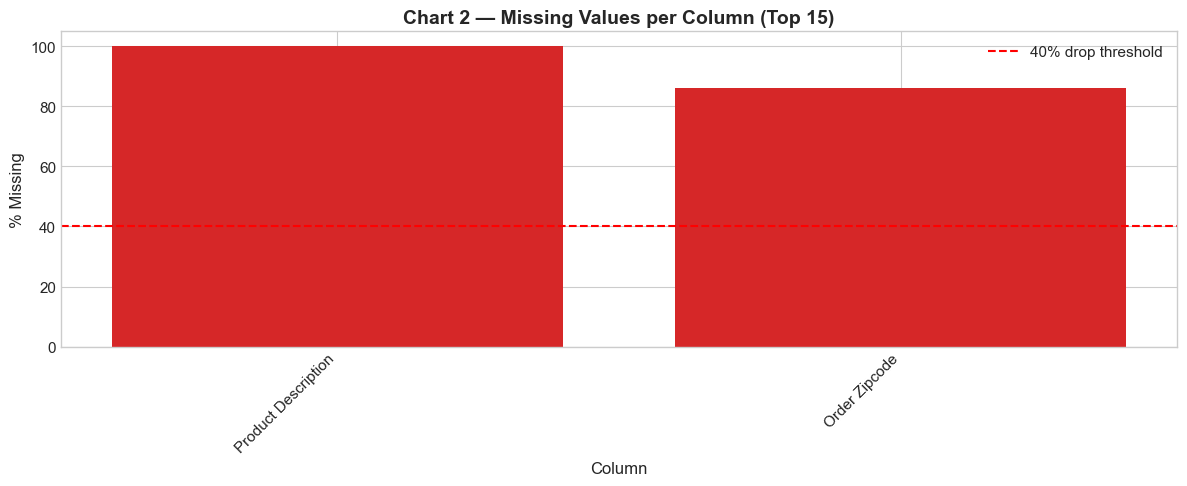

Chart saved: artifacts/chart2_missing_values.png


In [5]:
missing = df.isnull().mean().sort_values(ascending=False)
missing_pct = (missing * 100).round(2)

print("=== Missing Value Summary ===")
print(f"Columns with any missing: {(missing > 0).sum()}")
print(f"Columns with >40% missing: {(missing > 0.4).sum()}")
print()
print("Top 15 columns by % missing:")
print(missing_pct[missing_pct > 0].head(15).to_string())

# Chart 2: Missing Values Bar Chart
top_missing = missing_pct[missing_pct > 0].head(15)
if len(top_missing) > 0:
    fig, ax = plt.subplots(figsize=(12, 5))
    bars = ax.bar(top_missing.index, top_missing.values,
                  color=['#d62728' if v > 40 else '#1f77b4' for v in top_missing.values])
    ax.axhline(40, color='red', linestyle='--', linewidth=1.5, label='40% drop threshold')
    ax.set_xlabel('Column', fontsize=12)
    ax.set_ylabel('% Missing', fontsize=12)
    ax.set_title('Chart 2 — Missing Values per Column (Top 15)', fontsize=14, fontweight='bold')
    ax.legend()
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig('../artifacts/chart2_missing_values.png', bbox_inches='tight')
    plt.show()
    print("Chart saved: artifacts/chart2_missing_values.png")
else:
    print("No missing values detected.")


The target variable shows a moderate class imbalance — 54.8% of orders arrive late — which motivates using F1 rather than accuracy as the primary evaluation metric.

=== Target Class Distribution ===
  On-Time (0): 81,542  (45.2%)
  Late    (1): 98,977  (54.8%)


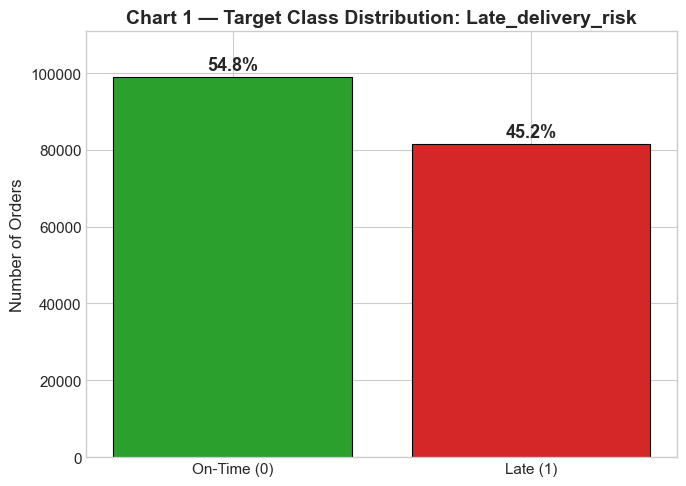

Chart saved: artifacts/chart1_class_distribution.png


In [6]:
target_counts = df['Late_delivery_risk'].value_counts()
target_pct = (df['Late_delivery_risk'].value_counts(normalize=True) * 100).round(1)

print("=== Target Class Distribution ===")
print(f"  On-Time (0): {target_counts[0]:,}  ({target_pct[0]}%)")
print(f"  Late    (1): {target_counts[1]:,}  ({target_pct[1]}%)")

# Chart 1: Class Distribution Bar Chart
fig, ax = plt.subplots(figsize=(7, 5))
colors = ['#2ca02c', '#d62728']
bars = ax.bar(['On-Time (0)', 'Late (1)'], target_counts.values, color=colors, edgecolor='black', linewidth=0.8)
for bar, pct in zip(bars, target_pct.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 800,
            f'{pct:.1f}%', ha='center', va='bottom', fontsize=13, fontweight='bold')
ax.set_ylabel('Number of Orders', fontsize=12)
ax.set_title('Chart 1 — Target Class Distribution: Late_delivery_risk', fontsize=14, fontweight='bold')
ax.set_ylim(0, max(target_counts.values) * 1.12)
plt.tight_layout()
plt.savefig('../artifacts/chart1_class_distribution.png', bbox_inches='tight')
plt.show()
print("Chart saved: artifacts/chart1_class_distribution.png")


A correlation heatmap exposes clusters of redundant numerical features that will be filtered out downstream.

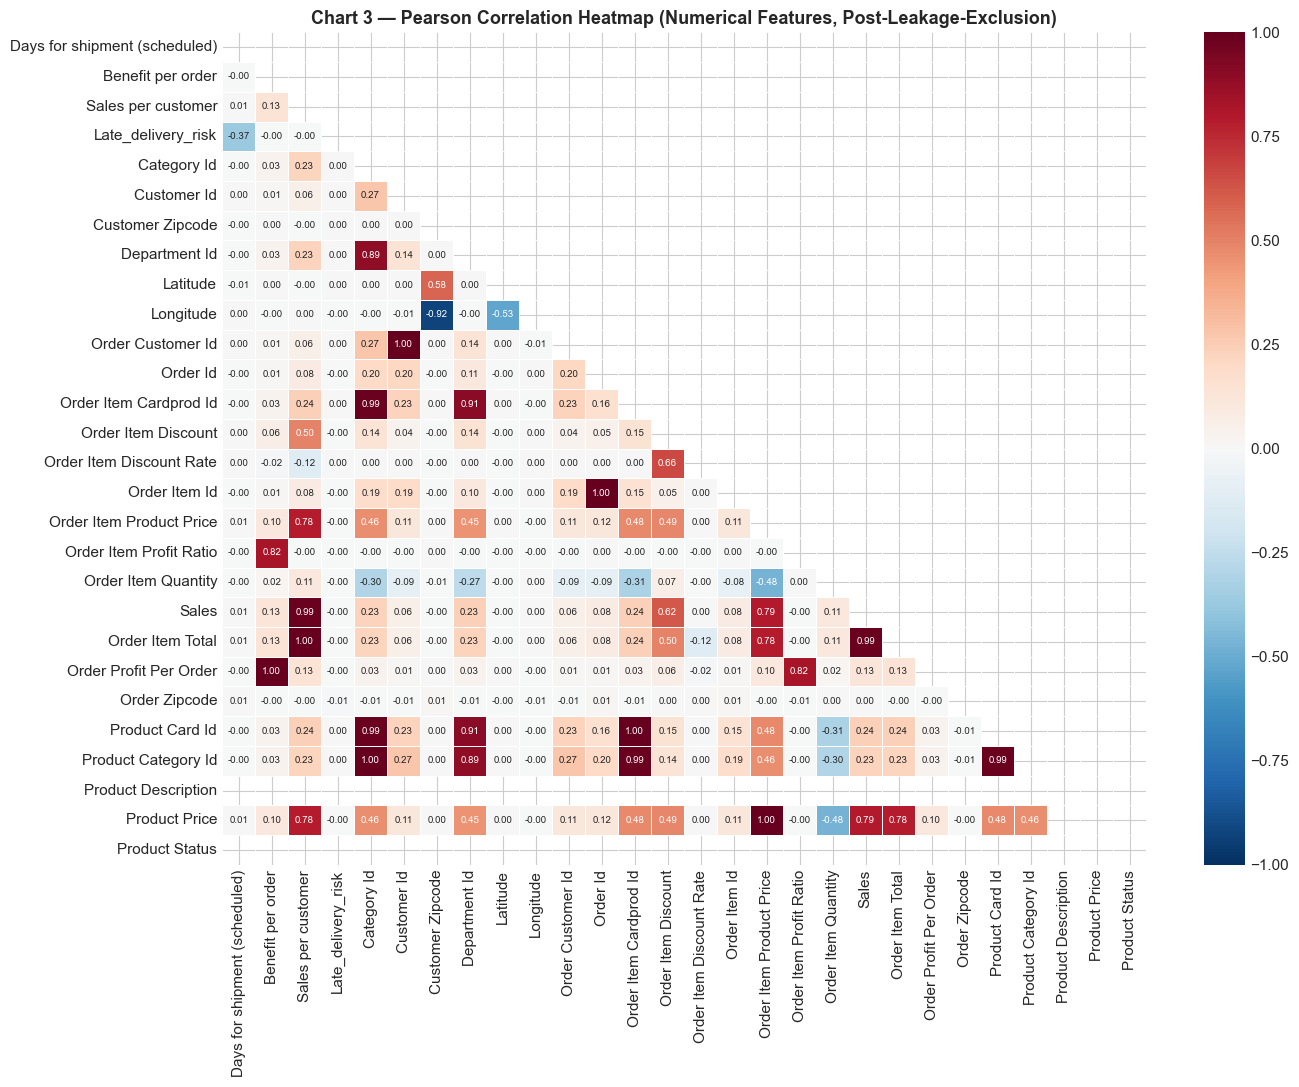

Chart saved: artifacts/chart3_correlation_heatmap.png

Feature pairs with |correlation| > 0.95:
  Order Customer Id ↔ Customer Id: 1.000
  Order Item Total ↔ Sales per customer: 1.000
  Order Profit Per Order ↔ Benefit per order: 1.000
  Product Card Id ↔ Order Item Cardprod Id: 1.000
  Product Category Id ↔ Category Id: 1.000
  Product Price ↔ Order Item Product Price: 1.000
  Order Item Id ↔ Order Id: 1.000
  Order Item Cardprod Id ↔ Category Id: 0.991
  Product Card Id ↔ Category Id: 0.991
  Product Category Id ↔ Order Item Cardprod Id: 0.991
  Product Category Id ↔ Product Card Id: 0.991
  Sales ↔ Sales per customer: 0.990
  Order Item Total ↔ Sales: 0.990


In [7]:
# Exclude known post-shipment leakage columns for the audit
leakage_for_audit = ['Days for shipping (real)', 'Delivery Status',
                     'shipping date (DateOrders)', 'Order Status']
audit_df = df.drop(columns=[c for c in leakage_for_audit if c in df.columns], errors='ignore')

# Numerical columns only
num_audit = audit_df.select_dtypes(include=[np.number])
corr = num_audit.corr()

# Chart 3: Correlation Heatmap
fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            annot=True, fmt='.2f', annot_kws={'size': 7},
            linewidths=0.5, ax=ax)
ax.set_title('Chart 3 — Pearson Correlation Heatmap (Numerical Features, Post-Leakage-Exclusion)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../artifacts/chart3_correlation_heatmap.png', bbox_inches='tight')
plt.show()
print("Chart saved: artifacts/chart3_correlation_heatmap.png")

# Identify high-correlation pairs
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
high_corr = [(col, row, upper.loc[row, col])
             for col in upper.columns
             for row in upper.index
             if abs(upper.loc[row, col]) > 0.95]
print(f"\nFeature pairs with |correlation| > 0.95:")
for c1, c2, v in sorted(high_corr, key=lambda x: abs(x[2]), reverse=True):
    print(f"  {c1} ↔ {c2}: {v:.3f}")


Box plots confirm the presence of outliers across key numerical features, motivating the winsorization step.

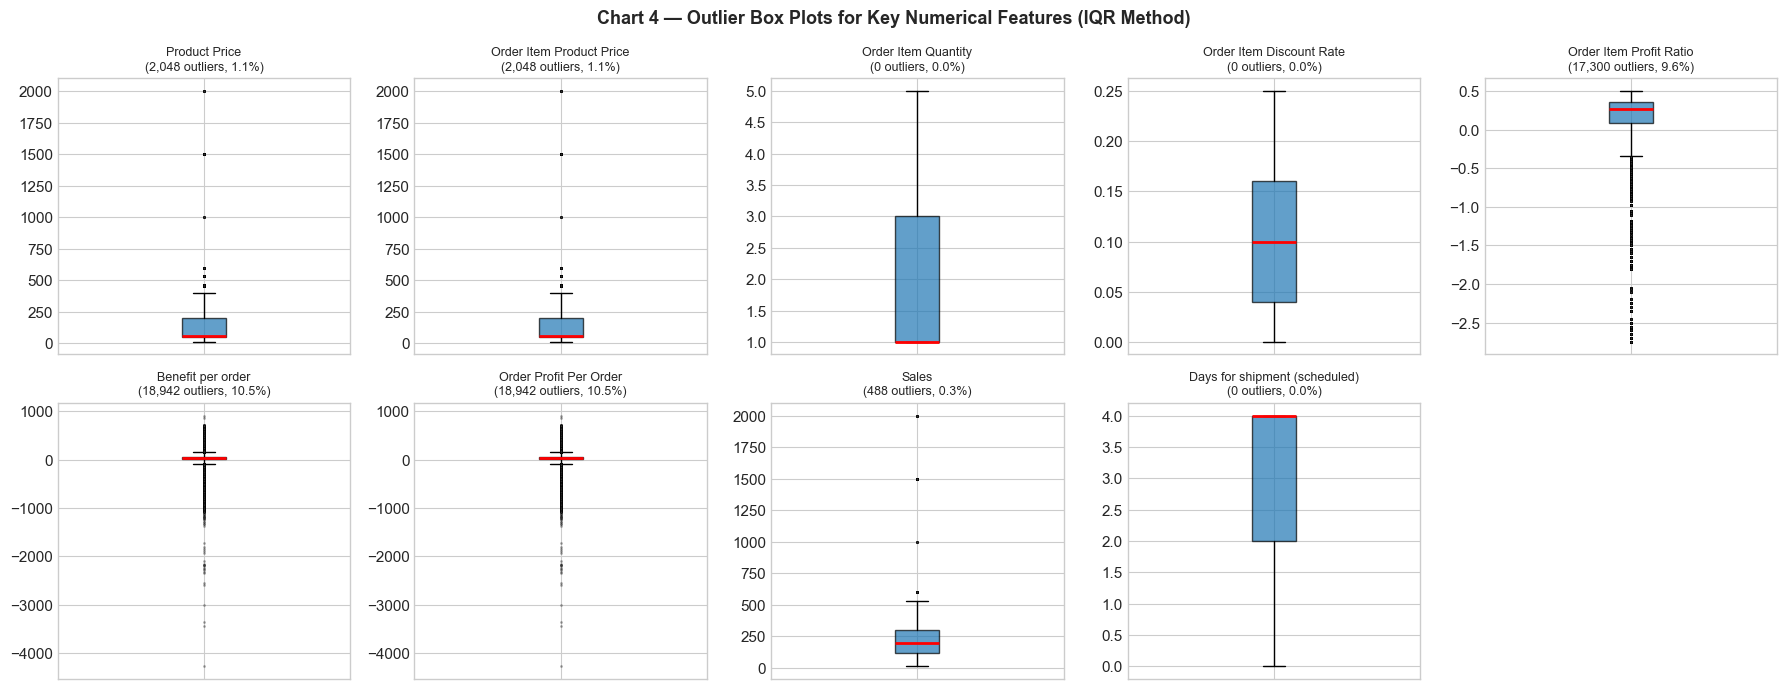

Chart saved: artifacts/chart4_outlier_boxplots.png

=== Outlier Summary (IQR method, 1.5×IQR rule) ===
  Product Price                           : 2,048 outliers (1.1%)
  Order Item Product Price                : 2,048 outliers (1.1%)
  Order Item Quantity                     :     0 outliers (0.0%)
  Order Item Discount Rate                :     0 outliers (0.0%)
  Order Item Profit Ratio                 : 17,300 outliers (9.6%)
  Benefit per order                       : 18,942 outliers (10.5%)
  Order Profit Per Order                  : 18,942 outliers (10.5%)
  Sales                                   :   488 outliers (0.3%)
  Days for shipment (scheduled)           :     0 outliers (0.0%)


In [8]:
# Key business-meaningful numerical features for outlier audit
outlier_candidates = [
    'Product Price', 'Order Item Product Price', 'Order Item Quantity',
    'Order Item Discount Rate', 'Order Item Profit Ratio',
    'Benefit per order', 'Order Profit Per Order', 'Sales',
    'Days for shipment (scheduled)'
]
outlier_cols = [c for c in outlier_candidates if c in df.columns]

fig, axes = plt.subplots(2, 5, figsize=(18, 7))
axes = axes.flatten()

for i, col in enumerate(outlier_cols[:10]):
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    n_outliers = ((df[col] < q1 - 1.5 * iqr) | (df[col] > q3 + 1.5 * iqr)).sum()
    pct = n_outliers / len(df) * 100

    axes[i].boxplot(df[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor='#1f77b4', alpha=0.7),
                    medianprops=dict(color='red', linewidth=2),
                    flierprops=dict(marker='.', markerfacecolor='gray', alpha=0.3, markersize=2))
    axes[i].set_title(f'{col}\n({n_outliers:,} outliers, {pct:.1f}%)', fontsize=9)
    axes[i].set_xticklabels([])

# Hide unused subplots
for j in range(len(outlier_cols), len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Chart 4 — Outlier Box Plots for Key Numerical Features (IQR Method)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../artifacts/chart4_outlier_boxplots.png', bbox_inches='tight')
plt.show()
print("Chart saved: artifacts/chart4_outlier_boxplots.png")

print("\n=== Outlier Summary (IQR method, 1.5×IQR rule) ===")
for col in outlier_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    n_out = ((df[col] < q1 - 1.5 * iqr) | (df[col] > q3 + 1.5 * iqr)).sum()
    print(f"  {col:40s}: {n_out:5,} outliers ({n_out/len(df)*100:.1f}%)")


Ten rows are isolated as an inference holdout **before any preprocessing** to simulate truly unseen production data arriving at the model for the first time.

In [9]:
# Extract 10-row inference holdout BEFORE any preprocessing
df_inference_raw = df.sample(10, random_state=RANDOM_STATE).copy()
df = df.drop(df_inference_raw.index).reset_index(drop=True)

print(f"Inference holdout: {len(df_inference_raw)} rows extracted")
print(f"Working dataset after holdout removal: {df.shape[0]:,} rows × {df.shape[1]} columns")
print()
print("Inference holdout — True labels (Late_delivery_risk):")
print(df_inference_raw[['Late_delivery_risk']].reset_index(drop=True).T.to_string())
print()
print("Inference holdout index values (original row numbers):")
print(df_inference_raw.index.tolist())


Inference holdout: 10 rows extracted
Working dataset after holdout removal: 180,509 rows × 53 columns

Inference holdout — True labels (Late_delivery_risk):
                    0  1  2  3  4  5  6  7  8  9
Late_delivery_risk  1  1  0  1  0  1  1  0  1  0

Inference holdout index values (original row numbers):
[80120, 19670, 114887, 120110, 56658, 99465, 40749, 22688, 154389, 47301]


Four post-shipment columns are dropped: they capture information that is only observable *after* delivery and would cause the model to cheat on training data while failing silently in production.

In [10]:
# Post-shipment columns — only observable after the order ships/delivers
LEAKAGE_COLS = [
    'Days for shipping (real)',    # actual transit time — post-delivery
    'Delivery Status',              # delivery outcome — post-delivery
    'shipping date (DateOrders)',   # actual dispatch date — post-order
    'Order Status',                 # completion/fraud status — post-fulfilment
]

cols_before = df.shape[1]
leakage_dropped = [c for c in LEAKAGE_COLS if c in df.columns]
df = df.drop(columns=leakage_dropped)

print(f"Leakage columns dropped: {leakage_dropped}")
print(f"Columns: {cols_before} → {df.shape[1]}")


Leakage columns dropped: ['Days for shipping (real)', 'Delivery Status', 'shipping date (DateOrders)', 'Order Status']
Columns: 53 → 49


Identifier and PII columns are detected programmatically using uniqueness and cardinality thresholds, then removed.

In [11]:
dropped_log = {}  # {col: rule}
n_rows = len(df)

# ── Rule 1: Uniqueness threshold > 95% ──────────────────────────────────────
high_unique = [
    c for c in df.columns
    if df[c].nunique() / n_rows > 0.95 and c != 'Late_delivery_risk'
]
for c in high_unique:
    dropped_log[c] = f"Rule 1 — uniqueness {df[c].nunique()/n_rows*100:.1f}% > 95%"

# ── Rule 2: Name-based keywords ──────────────────────────────────────────────
ID_KEYWORDS = ['id', 'email', 'password', 'image', 'url', 'fname', 'lname', 'phone']
name_based = [
    c for c in df.columns
    if any(kw in c.lower() for kw in ID_KEYWORDS) and c != 'Late_delivery_risk'
]
for c in name_based:
    if c not in dropped_log:
        kws = [kw for kw in ID_KEYWORDS if kw in c.lower()]
        dropped_log[c] = f"Rule 2 — name contains keyword(s): {kws}"

# ── Rule 3: Pattern-based (email / URL in content) ───────────────────────────
EMAIL_RE = re.compile(r'[a-zA-Z0-9._%+\-]+@[a-zA-Z0-9.\-]+\.[a-zA-Z]{2,}')
URL_RE   = re.compile(r'https?://|www\.')

pattern_based = []
for c in df.select_dtypes(include='object').columns:
    if c == 'Late_delivery_risk' or c in dropped_log:
        continue
    sample_vals = df[c].dropna().astype(str).head(200)
    has_email = sample_vals.str.contains(EMAIL_RE.pattern, regex=True).any()
    has_url   = sample_vals.str.contains(URL_RE.pattern,   regex=True).any()
    if has_email or has_url:
        pattern_based.append(c)
        dropped_log[c] = f"Rule 3 — content contains {'email' if has_email else 'URL'} pattern"

all_to_drop = list(dropped_log.keys())
df = df.drop(columns=[c for c in all_to_drop if c in df.columns])

print(f"Identifier columns removed: {len(all_to_drop)}")
print(f"Columns remaining: {df.shape[1]}")
print()
print("=== Dropped column log ===")
for col, rule in sorted(dropped_log.items()):
    print(f"  [{rule}]  →  '{col}'")


Identifier columns removed: 14
Columns remaining: 35

=== Dropped column log ===
  [Rule 2 — name contains keyword(s): ['id']]  →  'Category Id'
  [Rule 2 — name contains keyword(s): ['email']]  →  'Customer Email'
  [Rule 2 — name contains keyword(s): ['fname']]  →  'Customer Fname'
  [Rule 2 — name contains keyword(s): ['id']]  →  'Customer Id'
  [Rule 2 — name contains keyword(s): ['lname']]  →  'Customer Lname'
  [Rule 2 — name contains keyword(s): ['password']]  →  'Customer Password'
  [Rule 2 — name contains keyword(s): ['id']]  →  'Department Id'
  [Rule 2 — name contains keyword(s): ['id']]  →  'Order Customer Id'
  [Rule 2 — name contains keyword(s): ['id']]  →  'Order Id'
  [Rule 2 — name contains keyword(s): ['id']]  →  'Order Item Cardprod Id'
  [Rule 1 — uniqueness 100.0% > 95%]  →  'Order Item Id'
  [Rule 2 — name contains keyword(s): ['id']]  →  'Product Card Id'
  [Rule 2 — name contains keyword(s): ['id']]  →  'Product Category Id'
  [Rule 2 — name contains keyword(s)

The order date is parsed and decomposed into month, day-of-week, and quarter features to capture seasonal demand patterns.

In [12]:
# ── Parse order date and extract temporal features ───────────────────────────
date_col = 'order date (DateOrders)'
if date_col in df.columns:
    df[date_col] = pd.to_datetime(df[date_col], errors='coerce')
    df['order_month']      = df[date_col].dt.month.astype('Int64')
    df['order_dayofweek']  = df[date_col].dt.dayofweek.astype('Int64')
    df['order_quarter']    = df[date_col].dt.quarter.astype('Int64')
    n_invalid = df[date_col].isna().sum()
    df = df.drop(columns=[date_col])
    print(f"'{date_col}' parsed → 3 temporal features extracted "
          f"(invalid dates coerced to NaN: {n_invalid})")

# ── Data type audit for remaining columns ────────────────────────────────────
print()
print("=== Remaining column dtypes ===")
print(df.dtypes.to_string())
print()
print(f"Dataset shape after type validation: {df.shape}")


'order date (DateOrders)' parsed → 3 temporal features extracted (invalid dates coerced to NaN: 0)

=== Remaining column dtypes ===
Type                                 str
Days for shipment (scheduled)      int64
Benefit per order                float64
Sales per customer               float64
Late_delivery_risk                 int64
Category Name                        str
Customer City                        str
Customer Country                     str
Customer Segment                     str
Customer State                       str
Customer Street                      str
Customer Zipcode                 float64
Department Name                      str
Latitude                         float64
Longitude                        float64
Market                               str
Order City                           str
Order Country                        str
Order Item Discount              float64
Order Item Discount Rate         float64
Order Item Product Price         float64
Order I

Exact duplicate rows are detected and removed to avoid inflating training counts.

In [13]:
n_before = len(df)
n_dupes = df.duplicated().sum()
df = df.drop_duplicates().reset_index(drop=True)
n_after = len(df)

print(f"Exact duplicate rows detected: {n_dupes:,}")
print(f"Rows: {n_before:,} → {n_after:,} (removed {n_before - n_after:,})")


Exact duplicate rows detected: 0
Rows: 180,509 → 180,509 (removed 0)


Missing values are addressed using a three-tier strategy: drop columns with >40% missing, fill categorical columns with the mode, and numerical columns with the median.

In [14]:
imputation_values = {}  # saved for applying to inference set

# ── Step 1: Drop columns with > 40% missing ──────────────────────────────────
missing_frac = df.isnull().mean()
drop_high_missing = missing_frac[missing_frac > 0.40].index.tolist()
if drop_high_missing:
    df = df.drop(columns=drop_high_missing)
    print(f"Dropped (>40% missing): {drop_high_missing}")
else:
    print("No columns exceed the 40% missing threshold.")

# ── Step 2 & 3: Impute remaining missing values ───────────────────────────────
cols_with_missing = [c for c in df.columns if df[c].isna().any()]
print(f"\nColumns requiring imputation: {len(cols_with_missing)}")

for col in cols_with_missing:
    if df[col].dtype.kind in ('i', 'u', 'f', 'c') or str(df[col].dtype) in ('Int64', 'Float64'):
        # Numerical: median imputation
        val = df[col].median()
        df[col] = df[col].fillna(val)
        imputation_values[col] = float(val)
        print(f"  [Median] '{col}' ← {val:.4f}")
    else:
        # Categorical: mode imputation
        val = df[col].mode()[0]
        df[col] = df[col].fillna(val)
        imputation_values[col] = str(val)
        print(f"  [Mode]   '{col}' ← '{val}'")

# Temporal feature columns (Int64 nullable integers) may also have NaN
for col in ['order_month', 'order_dayofweek', 'order_quarter']:
    if col in df.columns and df[col].isna().any():
        val = int(df[col].median())
        df[col] = df[col].fillna(val)
        imputation_values[col] = val
        print(f"  [Median] '{col}' ← {val}")

print(f"\nDataset shape after imputation: {df.shape}")
print(f"Remaining missing values: {df.isnull().sum().sum()}")


Dropped (>40% missing): ['Order Zipcode', 'Product Description']

Columns requiring imputation: 1
  [Median] 'Customer Zipcode' ← 19380.0000

Dataset shape after imputation: (180509, 35)


Remaining missing values: 0


Extreme values are clipped at the 1st and 99th percentiles, preserving all rows while reducing the influence of outliers.

In [15]:
# Columns exempt from winsorisation
EXEMPT = {'Late_delivery_risk', 'order_month', 'order_dayofweek', 'order_quarter'}
num_cols_for_winsor = [
    c for c in df.select_dtypes(include=[np.number]).columns
    if c not in EXEMPT
]

winsor_log = []
for col in num_cols_for_winsor:
    p01 = df[col].quantile(0.01)
    p99 = df[col].quantile(0.99)
    n_clipped = ((df[col] < p01) | (df[col] > p99)).sum()
    df[col] = df[col].clip(lower=p01, upper=p99)
    if n_clipped > 0:
        winsor_log.append((col, p01, p99, n_clipped))

print(f"Numerical columns winsorised: {len(num_cols_for_winsor)}")
print()
print("=== Columns with clipped values (p01 – p99 bounds) ===")
print(f"{'Column':<40} {'p01':>10} {'p99':>10} {'Clipped':>10}")
print("-" * 74)
for col, p01, p99, n in sorted(winsor_log, key=lambda x: x[3], reverse=True)[:15]:
    print(f"{col:<40} {p01:>10.3f} {p99:>10.3f} {n:>10,}")
print()
print(f"Dataset shape after winsorisation: {df.shape}")


Numerical columns winsorised: 16

=== Columns with clipped values (p01 – p99 bounds) ===
Column                                          p01        p99    Clipped
--------------------------------------------------------------------------
Benefit per order                          -415.616    184.230      3,605
Order Profit Per Order                     -415.616    184.230      3,605
Latitude                                     18.201     45.359      3,599
Sales per customer                           22.490    464.950      3,550
Order Item Total                             22.490    464.950      3,550
Longitude                                  -123.032    -66.025      3,512
Order Item Product Price                     15.990    452.040      3,134
Product Price                                15.990    452.040      3,134
Customer Zipcode                            725.000  97301.000      2,626
Sales                                        24.990    499.950      2,492
Order Item Discount   

Near-zero-variance and highly correlated features are filtered out, reducing the feature space before encoding.

In [16]:
# Columns always protected from removal
PROTECTED = {'Late_delivery_risk'}

# ── Filter A: Near-zero variance ─────────────────────────────────────────────
num_cols_check = [c for c in df.select_dtypes(include=[np.number]).columns
                  if c not in PROTECTED]

low_var_cols = [
    c for c in num_cols_check
    if df[c].value_counts(normalize=True).iloc[0] > 0.99
]
if low_var_cols:
    df = df.drop(columns=low_var_cols)
    print(f"Filter A — Near-zero variance (>99% same value), dropped: {low_var_cols}")
else:
    print("Filter A — No near-zero variance columns detected.")

# ── Filter B: High correlation (> 0.95) ──────────────────────────────────────
num_cols_corr = [c for c in df.select_dtypes(include=[np.number]).columns
                 if c not in PROTECTED]
corr_matrix = df[num_cols_corr].corr().abs()
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

high_corr_drop = []
for col in upper_tri.columns:
    if col in high_corr_drop:
        continue
    correlated = upper_tri.index[upper_tri[col] > 0.95].tolist()
    for c2 in correlated:
        if c2 not in PROTECTED and c2 not in high_corr_drop:
            high_corr_drop.append(c2)
            print(f"Filter B — Dropping '{c2}' (corr={corr_matrix.loc[c2, col]:.3f} with '{col}')")

if high_corr_drop:
    df = df.drop(columns=high_corr_drop)
    print(f"\nFilter B — High correlation, total dropped: {len(high_corr_drop)}")
else:
    print("Filter B — No high-correlation pairs detected.")

print(f"\nDataset shape after feature selection: {df.shape}")
print(f"Columns remaining: {df.columns.tolist()}")


Filter A — Near-zero variance (>99% same value), dropped: ['Product Status']


Filter B — Dropping 'Customer Zipcode' (corr=0.961 with 'Longitude')
Filter B — Dropping 'Sales per customer' (corr=0.988 with 'Sales')
Filter B — Dropping 'Sales' (corr=0.988 with 'Order Item Total')
Filter B — Dropping 'Benefit per order' (corr=1.000 with 'Order Profit Per Order')
Filter B — Dropping 'Order Item Product Price' (corr=1.000 with 'Product Price')
Filter B — Dropping 'order_month' (corr=0.971 with 'order_quarter')

Filter B — High correlation, total dropped: 6

Dataset shape after feature selection: (180509, 28)
Columns remaining: ['Type', 'Days for shipment (scheduled)', 'Late_delivery_risk', 'Category Name', 'Customer City', 'Customer Country', 'Customer Segment', 'Customer State', 'Customer Street', 'Department Name', 'Latitude', 'Longitude', 'Market', 'Order City', 'Order Country', 'Order Item Discount', 'Order Item Discount Rate', 'Order Item Profit Ratio', 'Order Item Quantity', 'Order Item Total', 'Order Profit Per Order', 'Order Region', 'Order State', 'Product N

The feature matrix is partitioned into 15 categorical and 12 numerical columns for targeted encoding and scaling.

In [17]:
# ── Prepare X (features) and y (target) ──────────────────────────────────────
TARGET = 'Late_delivery_risk'
y = df[TARGET].copy()
X = df.drop(columns=[TARGET]).copy()

# ── Identify column types ────────────────────────────────────────────────────
cat_cols = X.select_dtypes(include='object').columns.tolist()
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()

print(f"Feature matrix X: {X.shape[0]:,} rows × {X.shape[1]} columns")
print(f"  Categorical columns ({len(cat_cols)}): {cat_cols}")
print(f"  Numerical columns  ({len(num_cols)}): {num_cols}")
print()
print(f"Target y: {y.shape[0]:,} values | classes: {sorted(y.unique())}")


Feature matrix X: 180,509 rows × 27 columns
  Categorical columns (15): ['Type', 'Category Name', 'Customer City', 'Customer Country', 'Customer Segment', 'Customer State', 'Customer Street', 'Department Name', 'Market', 'Order City', 'Order Country', 'Order Region', 'Order State', 'Product Name', 'Shipping Mode']
  Numerical columns  (12): ['Days for shipment (scheduled)', 'Latitude', 'Longitude', 'Order Item Discount', 'Order Item Discount Rate', 'Order Item Profit Ratio', 'Order Item Quantity', 'Order Item Total', 'Order Profit Per Order', 'Product Price', 'order_dayofweek', 'order_quarter']

Target y: 180,509 values | classes: [np.int64(0), np.int64(1)]


Category values appearing in fewer than 0.5% of rows are grouped into 'Other' to limit the size of the one-hot encoded space.

In [18]:
# Group rare categories into 'Other' (threshold: < 0.5% of rows)
RARE_THRESHOLD = 0.005
rare_summary = {}

for col in cat_cols:
    freq = X[col].value_counts(normalize=True)
    rare_cats = freq[freq < RARE_THRESHOLD].index.tolist()
    if rare_cats:
        X[col] = X[col].replace(rare_cats, 'Other')
        rare_summary[col] = len(rare_cats)

print("=== Rare category grouping (< 0.5% → 'Other') ===")
for col, n_rare in rare_summary.items():
    unique_after = X[col].nunique()
    print(f"  '{col}': {n_rare} rare categories merged → {unique_after} unique categories remain")

if not rare_summary:
    print("  No rare categories detected at the 0.5% threshold.")

print()
print("=== Final category cardinalities ===")
for col in cat_cols:
    print(f"  '{col}': {X[col].nunique()} unique values")

print()
print(f"X shape after rare-category grouping: {X.shape}")


=== Rare category grouping (< 0.5% → 'Other') ===
  'Category Name': 35 rare categories merged → 16 unique categories remain
  'Customer City': 547 rare categories merged → 17 unique categories remain
  'Customer State': 19 rare categories merged → 28 unique categories remain
  'Customer Street': 7458 rare categories merged → 1 unique categories remain
  'Department Name': 3 rare categories merged → 9 unique categories remain
  'Order City': 3580 rare categories merged → 18 unique categories remain
  'Order Country': 125 rare categories merged → 40 unique categories remain
  'Order Region': 1 rare categories merged → 23 unique categories remain
  'Order State': 1050 rare categories merged → 40 unique categories remain
  'Product Name': 109 rare categories merged → 10 unique categories remain

=== Final category cardinalities ===
  'Type': 4 unique values
  'Category Name': 16 unique values
  'Customer City': 17 unique values
  'Customer Country': 2 unique values
  'Customer Segment': 3

The data is split 80/20 with stratification, preserving the ~55/45 class ratio in both the training and test sets.

In [19]:
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

print(f"Training set:   {X_train_raw.shape[0]:,} rows × {X_train_raw.shape[1]} columns")
print(f"Test set:       {X_test_raw.shape[0]:,} rows × {X_test_raw.shape[1]} columns")
print()

# Verify stratification
train_dist = y_train.value_counts(normalize=True).sort_index() * 100
test_dist  = y_test.value_counts(normalize=True).sort_index() * 100
print("=== Class distribution verification (stratification check) ===")
print(f"{'Class':<10} {'Train %':>10} {'Test %':>10}")
for cls in sorted(y.unique()):
    print(f"{cls:<10} {train_dist[cls]:>10.2f} {test_dist[cls]:>10.2f}")


Training set:   144,407 rows × 27 columns
Test set:       36,102 rows × 27 columns

=== Class distribution verification (stratification check) ===
Class         Train %     Test %
0               45.17      45.17
1               54.83      54.83


A `OneHotEncoder` is fitted on the training set only, then applied to both train and test — no information from the test set leaks into the encoder.

In [20]:
# ── Fit encoder on TRAINING data only ────────────────────────────────────────
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
encoder.fit(X_train_raw[cat_cols])

# Transform both splits
X_train_cat = encoder.transform(X_train_raw[cat_cols])
X_test_cat  = encoder.transform(X_test_raw[cat_cols])
cat_feature_names = encoder.get_feature_names_out(cat_cols).tolist()

print(f"Categorical columns encoded: {len(cat_cols)} → {len(cat_feature_names)} OHE columns")
print()
print("OHE columns generated per input column:")
for col in cat_cols:
    ohe_cols = [c for c in cat_feature_names if c.startswith(col + '_')]
    print(f"  '{col}': {len(ohe_cols)} columns")
print()
print(f"X_train_cat shape: {X_train_cat.shape}")
print(f"X_test_cat  shape: {X_test_cat.shape}")


Categorical columns encoded: 15 → 220 OHE columns

OHE columns generated per input column:
  'Type': 4 columns
  'Category Name': 16 columns
  'Customer City': 17 columns
  'Customer Country': 2 columns
  'Customer Segment': 3 columns
  'Customer State': 28 columns
  'Customer Street': 1 columns
  'Department Name': 9 columns
  'Market': 5 columns
  'Order City': 18 columns
  'Order Country': 40 columns
  'Order Region': 23 columns
  'Order State': 40 columns
  'Product Name': 10 columns
  'Shipping Mode': 4 columns

X_train_cat shape: (144407, 220)
X_test_cat  shape: (36102, 220)


A `RobustScaler` is fitted on the training set only. It normalizes by the interquartile range rather than the standard deviation, making it robust to the outliers we identified earlier.

In [21]:
# ── Fit scaler on TRAINING data only ─────────────────────────────────────────
scaler = RobustScaler()
scaler.fit(X_train_raw[num_cols])

# Transform both splits
X_train_num = scaler.transform(X_train_raw[num_cols])
X_test_num  = scaler.transform(X_test_raw[num_cols])

# ── Concatenate: [numerical (scaled) | categorical (OHE)] ────────────────────
X_train_final = np.concatenate([X_train_num, X_train_cat], axis=1)
X_test_final  = np.concatenate([X_test_num,  X_test_cat],  axis=1)
feature_names = num_cols + cat_feature_names

print(f"Scaler fitted on {X_train_raw.shape[0]:,} training rows.")
print()
print(f"X_train final shape: {X_train_final.shape}  ({len(num_cols)} num + {len(cat_feature_names)} OHE)")
print(f"X_test  final shape: {X_test_final.shape}")
print(f"Total feature names: {len(feature_names)}")
print()
print("=== RobustScaler centres (medians) for first 5 numerical features ===")
for col, centre in zip(num_cols[:5], scaler.center_[:5]):
    print(f"  '{col}': median = {centre:.4f}")


Scaler fitted on 144,407 training rows.



X_train final shape: (144407, 232)  (12 num + 220 OHE)
X_test  final shape: (36102, 232)
Total feature names: 232

=== RobustScaler centres (medians) for first 5 numerical features ===
  'Days for shipment (scheduled)': median = 4.0000
  'Latitude': median = 33.1390
  'Longitude': median = -76.7579
  'Order Item Discount': median = 14.0000
  'Order Item Discount Rate': median = 0.0900


The frozen encoder and scaler are applied to the 10 inference holdout rows without any refitting.

In [22]:
# ── Step 1: Apply leakage removal ────────────────────────────────────────────
inf = df_inference_raw.copy()
leakage_in_inf = [c for c in LEAKAGE_COLS if c in inf.columns]
inf = inf.drop(columns=leakage_in_inf, errors='ignore')

# ── Step 2: Apply identifier removal ─────────────────────────────────────────
inf = inf.drop(columns=[c for c in all_to_drop if c in inf.columns], errors='ignore')

# ── Step 3: Parse date column and extract temporal features ───────────────────
if date_col in inf.columns:
    inf[date_col] = pd.to_datetime(inf[date_col], errors='coerce')
    inf['order_month']     = inf[date_col].dt.month.astype('Int64')
    inf['order_dayofweek'] = inf[date_col].dt.dayofweek.astype('Int64')
    inf['order_quarter']   = inf[date_col].dt.quarter.astype('Int64')
    inf = inf.drop(columns=[date_col])

# ── Step 4: Impute missing values using stored training imputation values ─────
for col, val in imputation_values.items():
    if col in inf.columns and inf[col].isna().any():
        inf[col] = inf[col].fillna(val)

# ── Step 5: Drop the same leakage/corr columns removed by the filters ─────────
cols_to_remove_inf = (
    [c for c in drop_high_missing if c in inf.columns] +
    [c for c in low_var_cols if c in inf.columns] +
    [c for c in high_corr_drop if c in inf.columns]
)
inf = inf.drop(columns=cols_to_remove_inf, errors='ignore')

# ── Step 6: Align columns with X (ensure same column set) ────────────────────
# Separate target
inf_y = inf['Late_delivery_risk'].copy()
inf_X = inf.drop(columns=['Late_delivery_risk'], errors='ignore')

# Group rare categories (use same vocabulary as training)
for col in cat_cols:
    if col in inf_X.columns:
        known_cats = set(X[col].unique())
        inf_X[col] = inf_X[col].apply(lambda v: v if v in known_cats else 'Other')

# ── Step 7: Encode with fitted encoder ───────────────────────────────────────
inf_cat_cols = [c for c in cat_cols if c in inf_X.columns]
inf_num_cols = [c for c in num_cols if c in inf_X.columns]

inf_cat = encoder.transform(inf_X[inf_cat_cols].reindex(columns=cat_cols, fill_value='Other'))
inf_num = scaler.transform(inf_X[inf_num_cols].reindex(columns=num_cols, fill_value=0))

df_inference_processed = np.concatenate([inf_num, inf_cat], axis=1)

print(f"Inference holdout processed: {df_inference_processed.shape}")
print(f"  Feature vector length matches training: {df_inference_processed.shape[1] == X_train_final.shape[1]}")
print(f"  True labels: {inf_y.values.tolist()}")


Inference holdout processed: (10, 232)
  Feature vector length matches training: True
  True labels: [1, 1, 0, 1, 0, 1, 1, 0, 1, 0]


All preprocessing outputs — feature matrices, labels, encoders, scalers, and the inference holdout — are saved to a single pickle file.

In [23]:
artifact = {
    'X_train':               X_train_final,
    'X_test':                X_test_final,
    'y_train':               y_train.reset_index(drop=True),
    'y_test':                y_test.reset_index(drop=True),
    'df_inference_raw':      df_inference_raw,
    'df_inference_processed': df_inference_processed,
    'scaler':                scaler,
    'encoder':               encoder,
    'feature_names':         feature_names,
    'target_name':           TARGET,
    # Metadata for downstream validation
    '_meta': {
        'n_train':           X_train_final.shape[0],
        'n_test':            X_test_final.shape[0],
        'n_features':        len(feature_names),
        'n_cat_features':    len(cat_feature_names),
        'n_num_features':    len(num_cols),
        'cat_cols':          cat_cols,
        'num_cols':          num_cols,
        'imputation_values': imputation_values,
        'leakage_cols_removed': LEAKAGE_COLS,
        'identifier_cols_removed': all_to_drop,
        'random_state':      RANDOM_STATE,
    }
}

with open(ARTIFACT_PATH, 'wb') as f:
    pickle.dump(artifact, f)

print(f"Artifact saved: {ARTIFACT_PATH}")
print(f"  Keys: {list(artifact.keys())}")
print()
print("=== Artifact Contents Summary ===")
print(f"  X_train shape:               {artifact['X_train'].shape}")
print(f"  X_test shape:                {artifact['X_test'].shape}")
print(f"  y_train shape:               {artifact['y_train'].shape}")
print(f"  y_test shape:                {artifact['y_test'].shape}")
print(f"  df_inference_raw shape:      {artifact['df_inference_raw'].shape}")
print(f"  df_inference_processed shape:{artifact['df_inference_processed'].shape}")
print(f"  feature_names (total):       {len(artifact['feature_names'])}")
print(f"    — numerical features:      {artifact['_meta']['n_num_features']}")
print(f"    — OHE columns:             {artifact['_meta']['n_cat_features']}")
print(f"  target_name:                 {artifact['target_name']}")
print(f"  scaler type:                 {type(artifact['scaler']).__name__}")
print(f"  encoder type:                {type(artifact['encoder']).__name__}")


Artifact saved: ../artifacts/prepared_data.pkl
  Keys: ['X_train', 'X_test', 'y_train', 'y_test', 'df_inference_raw', 'df_inference_processed', 'scaler', 'encoder', 'feature_names', 'target_name', '_meta']

=== Artifact Contents Summary ===
  X_train shape:               (144407, 232)
  X_test shape:                (36102, 232)
  y_train shape:               (144407,)
  y_test shape:                (36102,)
  df_inference_raw shape:      (10, 53)
  df_inference_processed shape:(10, 232)
  feature_names (total):       232
    — numerical features:      12
    — OHE columns:             220
  target_name:                 Late_delivery_risk
  scaler type:                 RobustScaler
  encoder type:                OneHotEncoder


Six sanity checks confirm zero missing values, consistent feature dimensions, and correct class ratios across both splits.

In [24]:
# ── Final sanity checks ──────────────────────────────────────────────────────
print("=== FINAL SANITY CHECKS ===")

# 1. No NaN in training or test arrays
assert not np.isnan(X_train_final).any(), "NaN detected in X_train!"
assert not np.isnan(X_test_final).any(),  "NaN detected in X_test!"
print("✓ No NaN values in X_train or X_test")

# 2. Shapes consistent
assert X_train_final.shape[1] == X_test_final.shape[1] == len(feature_names)
print(f"✓ Feature count consistent: {len(feature_names)} columns in train, test, and feature_names")

# 3. Inference processed shape matches
assert df_inference_processed.shape[1] == X_train_final.shape[1]
print(f"✓ Inference holdout feature count matches: {df_inference_processed.shape[1]}")

# 4. Target is binary
assert set(y_train.unique()) <= {0, 1}, "Non-binary values in y_train!"
assert set(y_test.unique())  <= {0, 1}, "Non-binary values in y_test!"
print(f"✓ Target is binary: values = {sorted(y_train.unique())}")

# 5. Class balance preserved
train_late_pct = y_train.mean() * 100
test_late_pct  = y_test.mean() * 100
assert abs(train_late_pct - test_late_pct) < 1.0, "Stratification failed!"
print(f"✓ Class balance preserved: train {train_late_pct:.1f}% late | test {test_late_pct:.1f}% late")

# 6. Pickle loads cleanly
with open(ARTIFACT_PATH, 'rb') as f:
    loaded = pickle.load(f)
assert set(loaded.keys()) >= {'X_train','X_test','y_train','y_test',
                               'df_inference_raw','df_inference_processed',
                               'scaler','encoder','feature_names','target_name'}
print(f"✓ Pickle loads successfully with all required keys")

print()
print("All checks passed. Preprocessing notebook complete.")


=== FINAL SANITY CHECKS ===
✓ No NaN values in X_train or X_test
✓ Feature count consistent: 232 columns in train, test, and feature_names
✓ Inference holdout feature count matches: 232
✓ Target is binary: values = [np.int64(0), np.int64(1)]
✓ Class balance preserved: train 54.8% late | test 54.8% late


✓ Pickle loads successfully with all required keys

All checks passed. Preprocessing notebook complete.


---
## 2. k-Nearest Neighbors

k-NN classifies each order by majority vote among its *k* closest neighbors in the 232-dimensional feature space, using a distance metric to measure similarity. It makes no assumptions about the data distribution, making it a solid non-parametric baseline. However, its O(n·d) inference cost scales poorly with dataset size, so we subsample the training set to 25,000 rows before fitting.

We load all required modules and the preprocessed artifact.

In [1]:
# Step 1: Import standard data-science and sklearn libraries
import pickle
import contextlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

import joblib
from tqdm.auto import tqdm

from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import (GridSearchCV, StratifiedKFold,
                                     cross_val_score)
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix,
                              ConfusionMatrixDisplay)
from sklearn.utils import resample

# Step 2: Define a context manager that wires tqdm into joblib's batch callback
# This makes GridSearchCV (which uses joblib internally) report progress per completed fit
@contextlib.contextmanager
def tqdm_joblib(tqdm_object):
    class TqdmBatchCompletionCallback(joblib.parallel.BatchCompletionCallBack):
        def __call__(self, *args, **kwargs):
            tqdm_object.update(n=self.batch_size)
            return super().__call__(*args, **kwargs)
    old_callback = joblib.parallel.BatchCompletionCallBack
    joblib.parallel.BatchCompletionCallBack = TqdmBatchCompletionCallback
    try:
        yield tqdm_object
    finally:
        joblib.parallel.BatchCompletionCallBack = old_callback
        tqdm_object.close()

# Step 3: Resolve paths — try notebook-relative path first, then repo-root fallback
_candidates = [
    Path('../artifacts/prepared_data.pkl'),  # CWD = notebooks/
    Path('artifacts/prepared_data.pkl'),      # CWD = repo root
]
ARTIFACTS_PATH = next(p for p in _candidates if p.exists())
RESULTS_DIR    = ARTIFACTS_PATH.parent.parent / 'results'
RESULTS_DIR.mkdir(exist_ok=True)
print(f"Artifacts path : {ARTIFACTS_PATH}")
print(f"Results dir    : {RESULTS_DIR}")

# Step 4: Load the prepared data dictionary produced by the preprocessing step
with open(ARTIFACTS_PATH, 'rb') as f:
    data = pickle.load(f)

# Step 5: Extract the required arrays and metadata
X_train       = data['X_train']
X_test        = data['X_test']
y_train       = data['y_train']
y_test        = data['y_test']
feature_names = data['feature_names']

# Step 6: Print a quick sanity check on dimensions and class balance
print(f"\nX_train shape : {X_train.shape}")
print(f"X_test  shape : {X_test.shape}")
print(f"Features      : {len(feature_names)}")
print(f"y_train dist  : {dict(pd.Series(y_train).value_counts())}")

Artifacts path : ../artifacts/prepared_data.pkl
Results dir    : ../results

X_train shape : (144407, 232)
X_test  shape : (36102, 232)
Features      : 232
y_train dist  : {1: np.int64(79177), 0: np.int64(65230)}


The training set is subsampled to 25,000 stratified rows to keep grid search and inference time feasible.

In [2]:
# Step 1: Subsample X_train and y_train to 25,000 rows without replacement
# Step 2: stratify=y_train preserves the original class ratio (~55/45) in the subsample
# Step 3: replace=False ensures a pure subsample — no duplicate rows
X_train_knn, y_train_knn = resample(
    X_train, y_train,
    n_samples=25_000,
    replace=False,
    stratify=y_train,
    random_state=42,
)

print(f"Subsampled shape   : {X_train_knn.shape}")
print(f"Class balance      : {dict(pd.Series(y_train_knn).value_counts())}")
print(f"Late ratio (subsample): {pd.Series(y_train_knn).mean():.3f}")
print(f"Late ratio (full train): {pd.Series(y_train).mean():.3f}")

Subsampled shape   : (25000, 232)
Class balance      : {1: np.int64(13707), 0: np.int64(11293)}
Late ratio (subsample): 0.548
Late ratio (full train): 0.548


We search over neighborhood size k (1 to 21, odd values), distance metric (Euclidean / Manhattan), and weighting strategy (uniform / distance-weighted).

In [3]:
# Step 1: Define the KNeighborsClassifier
# - algorithm='ball_tree': 
# - n_jobs=1: single-threaded to prevent nested parallelism with GridSearchCV on M1/Colab
knn = KNeighborsClassifier(algorithm='ball_tree', n_jobs=1)

# Step 2: Define the hyperparameter grid (from the hyperparameter search space)
param_grid = {
    'n_neighbors': [3, 5, 7, 11, 15],
    'metric':      ['euclidean', 'manhattan'],
    'weights':     ['uniform', 'distance'],
}

# Step 3: Wrap in GridSearchCV — n_jobs=-1 parallelises across combinations, not within each KNN fit
# verbose=0: progress is tracked by tqdm in the next cell instead
grid_search = GridSearchCV(
    estimator=knn,
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=0,
    return_train_score=False,
)

n_combos = (len(param_grid['n_neighbors'])
            * len(param_grid['metric'])
            * len(param_grid['weights']))
print(f"Grid combinations : {n_combos}")
print(f"Total CV fits     : {n_combos * 5}  ({n_combos} combos × 5 folds)")

Grid combinations : 20
Total CV fits     : 100  (20 combos × 5 folds)


GridSearchCV with 5-fold stratified cross-validation evaluates all 20 combinations and selects the one with the highest mean F1.

In [4]:
# Step 1: Fit GridSearchCV on the 25K subsampled training data
# Step 2: tqdm_joblib wraps joblib's batch callback so each completed fit increments the bar
# Step 3: total=100 because 20 combinations × 5 folds = 100 fits
with tqdm_joblib(tqdm(desc="GridSearchCV (k-NN)", total=n_combos * 5, unit="fit")):
    grid_search.fit(X_train_knn, y_train_knn)

# Step 4: Display the best hyperparameters and their mean CV F1 score
print("\nBest hyperparameters :", grid_search.best_params_)
print(f"Best CV F1 score     : {grid_search.best_score_:.4f}")

GridSearchCV (k-NN):   0%|          | 0/100 [00:00<?, ?fit/s]


Best hyperparameters : {'metric': 'manhattan', 'n_neighbors': 15, 'weights': 'distance'}
Best CV F1 score     : 0.6747


The best model is applied to the held-out test set and all five metrics are computed.

In [5]:
# Step 1: Retrieve the best estimator (already refit on full X_train_knn by GridSearchCV)
best_knn = grid_search.best_estimator_

# Step 2: Predict class labels on the full held-out test set
y_pred  = best_knn.predict(X_test)

# Step 3: Predict class probabilities for ROC-AUC and PR-curve computation
y_proba = best_knn.predict_proba(X_test)[:, 1]

# Step 4: Compute F1 on the subsampled training set (used in the overfitting comparison chart)
train_f1 = f1_score(y_train_knn, best_knn.predict(X_train_knn), zero_division=0)

# Step 5: Compute all five evaluation metrics on the test set
metrics = {
    'accuracy':  accuracy_score(y_test,  y_pred),
    'precision': precision_score(y_test, y_pred, zero_division=0),
    'recall':    recall_score(y_test,    y_pred, zero_division=0),
    'f1':        f1_score(y_test,        y_pred, zero_division=0),
    'roc_auc':   roc_auc_score(y_test,   y_proba),
}
test_f1 = metrics['f1']

# Step 6: Print all metrics
print("=== k-NN Test Set Metrics ===")
for name, val in metrics.items():
    print(f"  {name:<12}: {val:.4f}")
print(f"\n  train_f1  (subsample) : {train_f1:.4f}")
print(f"  test_f1               : {test_f1:.4f}")
print(f"  gap (train - test)    : {train_f1 - test_f1:.4f}")

=== k-NN Test Set Metrics ===
  accuracy    : 0.6605
  precision   : 0.7014
  recall      : 0.6631
  f1          : 0.6817
  roc_auc     : 0.7158

  train_f1  (subsample) : 1.0000
  test_f1               : 0.6817
  gap (train - test)    : 0.3183


The confusion matrix shows the counts of correct and incorrect predictions across both classes.

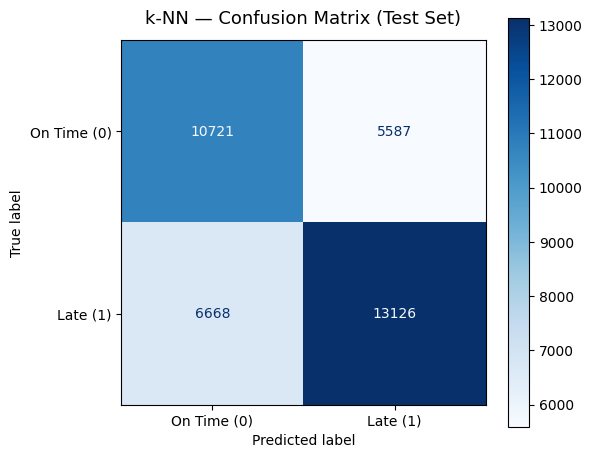

True Negatives  (On-Time correctly classified) : 10,721
False Positives (On-Time predicted as Late)    : 5,587
False Negatives (Late orders missed by model)  : 6,668
True Positives  (Late orders correctly flagged): 13,126


In [6]:
# Step 1: Compute the confusion matrix from test set predictions
cm = confusion_matrix(y_test, y_pred)

# Step 2: Plot the confusion matrix using sklearn's ConfusionMatrixDisplay
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['On Time (0)', 'Late (1)'])
disp.plot(ax=ax, colorbar=True, cmap='Blues')

# Step 3: Add title and save the figure to the results folder
ax.set_title('k-NN — Confusion Matrix (Test Set)', fontsize=13, pad=12)
plt.tight_layout()
plt.savefig(str(RESULTS_DIR / 'knn_confusion_matrix.png'), dpi=150, bbox_inches='tight')
plt.show()

# Step 4: Print raw counts for reference
tn, fp, fn, tp = cm.ravel()
print(f"True Negatives  (On-Time correctly classified) : {tn:,}")
print(f"False Positives (On-Time predicted as Late)    : {fp:,}")
print(f"False Negatives (Late orders missed by model)  : {fn:,}")
print(f"True Positives  (Late orders correctly flagged): {tp:,}")

The k vs. F1 validation curve reveals the bias–variance tradeoff: small k overfits to local noise, large k under-fits by averaging too broadly.

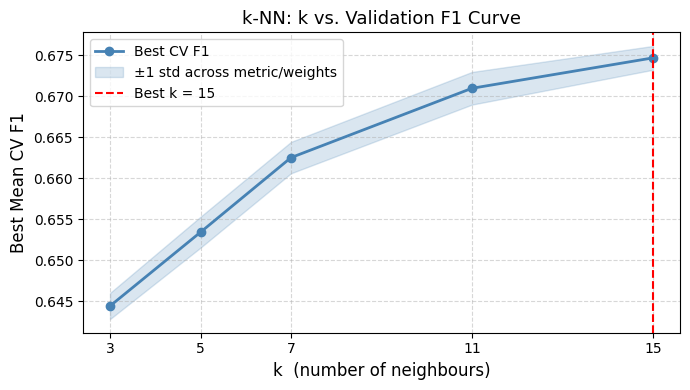

 k  best_cv_f1
 3    0.644408
 5    0.653405
 7    0.662496
11    0.670946
15    0.674652


In [7]:
# Step 1: Load GridSearchCV cv_results_ into a DataFrame
cv_df = pd.DataFrame(grid_search.cv_results_)

# Step 2: For each k, take the best mean CV F1 across all metric/weights combinations
k_f1 = (
    cv_df
    .groupby('param_n_neighbors')['mean_test_score']
    .max()
    .reset_index()
    .rename(columns={'param_n_neighbors': 'k', 'mean_test_score': 'best_cv_f1'})
)

# Step 3: Compute the spread (std) across metric/weights combos for each k as an error band
k_std = (
    cv_df
    .groupby('param_n_neighbors')['mean_test_score']
    .std()
    .reset_index()
    .rename(columns={'param_n_neighbors': 'k', 'mean_test_score': 'std_cv_f1'})
)
k_plot = k_f1.merge(k_std, on='k')

# Step 4: Plot k vs. F1 with an error ribbon
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(k_plot['k'], k_plot['best_cv_f1'],
        marker='o', linewidth=2, color='steelblue', label='Best CV F1')
ax.fill_between(
    k_plot['k'],
    k_plot['best_cv_f1'] - k_plot['std_cv_f1'],
    k_plot['best_cv_f1'] + k_plot['std_cv_f1'],
    alpha=0.2, color='steelblue', label='±1 std across metric/weights'
)

# Step 5: Mark the best k chosen by GridSearchCV with a vertical red dashed line
best_k = grid_search.best_params_['n_neighbors']
ax.axvline(x=best_k, color='red', linestyle='--',
           linewidth=1.5, label=f'Best k = {best_k}')

ax.set_xlabel('k  (number of neighbours)', fontsize=12)
ax.set_ylabel('Best Mean CV F1', fontsize=12)
ax.set_title('k-NN: k vs. Validation F1 Curve', fontsize=13)
ax.set_xticks(k_plot['k'])
ax.legend()
ax.grid(True, linestyle='--', alpha=0.5)

# Step 6: Save the figure
plt.tight_layout()
plt.savefig(str(RESULTS_DIR / 'knn_k_vs_f1.png'), dpi=150, bbox_inches='tight')
plt.show()
print(k_plot[['k', 'best_cv_f1']].to_string(index=False))

5-fold cross-validation on the subsampled training set confirms that the chosen k generalizes consistently across folds.

In [8]:
# Step 1: Define a 5-fold stratified cross-validator with a fixed random seed
cv_splitter = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Step 2: Run cross-validation on the subsampled training set using the best estimator
cv_f1_scores = cross_val_score(
    best_knn, X_train_knn, y_train_knn,
    cv=cv_splitter,
    scoring='f1',
)

# Step 3: Print per-fold scores and summary statistics
print("5-Fold Stratified CV F1 Scores (subsampled training set):")
for i, score in enumerate(cv_f1_scores, start=1):
    print(f"  Fold {i}: {score:.4f}")
print(f"\n  Mean ± Std : {cv_f1_scores.mean():.4f} ± {cv_f1_scores.std():.4f}")
print(f"  Min / Max  : {cv_f1_scores.min():.4f} / {cv_f1_scores.max():.4f}")

5-Fold Stratified CV F1 Scores (subsampled training set):
  Fold 1: 0.6879
  Fold 2: 0.6693
  Fold 3: 0.6669
  Fold 4: 0.6737
  Fold 5: 0.6814

  Mean ± Std : 0.6758 ± 0.0078
  Min / Max  : 0.6669 / 0.6879


In [9]:
# Step 1: Build and save the results dictionary
results = {
    'model_name':         'k-NN',
    'model':              best_knn,
    'best_params':        grid_search.best_params_,
    'y_pred':             y_pred,
    'y_proba':            y_proba,
    'metrics':            metrics,
    'cv_f1_scores':       cv_f1_scores,
    'train_f1':           train_f1,
    'test_f1':            test_f1,
    'feature_importance': None,   # k-NN does not produce feature importances
}

# Step 2: Assert all required top-level keys are present (schema validator)
required_keys = {
    'model_name', 'model', 'best_params', 'y_pred', 'y_proba',
    'metrics', 'cv_f1_scores', 'train_f1', 'test_f1', 'feature_importance',
}
assert set(results.keys()) == required_keys, \
    f"Schema mismatch — missing: {required_keys - set(results.keys())}"

# Step 3: Assert the 'metrics' sub-dict has all five required metric keys
required_metric_keys = {'accuracy', 'precision', 'recall', 'f1', 'roc_auc'}
assert set(results['metrics'].keys()) == required_metric_keys, \
    f"Metrics mismatch — missing: {required_metric_keys - set(results['metrics'].keys())}"

# Step 4: Save to results/knn_results.pkl
output_path = RESULTS_DIR / 'knn_results.pkl'
with open(output_path, 'wb') as f:
    pickle.dump(results, f)

print(f"Saved   : {output_path}")
print(f"Keys    : {list(results.keys())}")
print("Metrics :")
for k, v in results['metrics'].items():
    print(f"  {k:<12}: {v:.4f}")

Saved   : ../results/knn_results.pkl
Keys    : ['model_name', 'model', 'best_params', 'y_pred', 'y_proba', 'metrics', 'cv_f1_scores', 'train_f1', 'test_f1', 'feature_importance']
Metrics :
  accuracy    : 0.6605
  precision   : 0.7014
  recall      : 0.6631
  f1          : 0.6817
  roc_auc     : 0.7158


---
## 3. SGD Classifier

The SGD Classifier fits a linear decision boundary by minimizing a differentiable loss function with stochastic gradient descent. We use the `modified_huber` loss, which produces calibrated probability estimates and is robust to label noise. The regularization parameter alpha penalizes large weight magnitudes, controlling how aggressively the model is constrained — a higher alpha produces a simpler model that trades some bias for lower variance.

We load all required modules and the preprocessed artifact.

In [1]:
import pickle
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import SGDClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report
)

warnings.filterwarnings('ignore')
np.random.seed(42)

print('Imports OK')

Imports OK


In [2]:
ARTIFACT_PATH = '../artifacts/prepared_data.pkl'
RESULTS_PATH  = '../results/sgd_results.pkl'

with open(ARTIFACT_PATH, 'rb') as f:
    data = pickle.load(f)

X_train        = data['X_train']
X_test         = data['X_test']
y_train        = data['y_train']
y_test         = data['y_test']
feature_names  = data['feature_names']

print(f'X_train shape : {X_train.shape}')
print(f'X_test  shape : {X_test.shape}')
print(f'y_train class balance : {np.bincount(y_train)}')
print(f'y_test  class balance : {np.bincount(y_test)}')
print(f'Number of features    : {len(feature_names)}')

X_train shape : (144407, 232)
X_test  shape : (36102, 232)
y_train class balance : [65230 79177]
y_test  class balance : [16308 19794]
Number of features    : 232


The grid covers regularization strength (alpha), initial learning rate (eta0), and maximum training iterations.

In [3]:
param_grid = {
    'alpha'    : [0.0001, 0.001, 0.01],
    'eta0'     : [0.001, 0.01, 0.1],
    'max_iter' : [500, 1000],
}

total_fits = (len(param_grid['alpha']) *
              len(param_grid['eta0'])  *
              len(param_grid['max_iter']) * 5)  # 5-fold CV

print(f'Grid size          : {len(param_grid["alpha"]) * len(param_grid["eta0"]) * len(param_grid["max_iter"])} combinations')
print(f'Total model fits   : {total_fits}  (combinations × 5 CV folds)')

Grid size          : 18 combinations
Total model fits   : 90  (combinations × 5 CV folds)


GridSearchCV with 5-fold CV evaluates all 18 combinations and selects the best by mean F1.

In [4]:
base_sgd = SGDClassifier(
    loss='modified_huber',
    learning_rate='constant',
    random_state=42
)

grid_search = GridSearchCV(
    estimator  = base_sgd,
    param_grid = param_grid,
    cv         = 5,
    scoring    = 'f1',
    n_jobs     = -1,
    verbose    = 1,
    refit      = True   # refit best model on full X_train after CV
)

print('Fitting GridSearchCV ...')
grid_search.fit(X_train, y_train)
print('Done.')

Fitting GridSearchCV ...
Fitting 5 folds for each of 18 candidates, totalling 90 fits


Done.


The best hyperparameters and their cross-validated F1 score are printed.

In [5]:
best_params    = grid_search.best_params_
best_cv_score  = grid_search.best_score_
best_estimator = grid_search.best_estimator_

print('Best hyperparameters:')
for k, v in best_params.items():
    print(f'  {k:12s} = {v}')
print(f'\nBest CV F1 (mean over 5 folds) : {best_cv_score:.4f}')

Best hyperparameters:
  alpha        = 0.01
  eta0         = 0.001
  max_iter     = 500

Best CV F1 (mean over 5 folds) : 0.6694


The best model is evaluated on the held-out test set.

In [6]:
y_pred  = best_estimator.predict(X_test)
y_proba = best_estimator.predict_proba(X_test)[:, 1]

accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall    = recall_score(y_test, y_pred, zero_division=0)
f1        = f1_score(y_test, y_pred, zero_division=0)
roc_auc   = roc_auc_score(y_test, y_proba)

# Train F1 for train-vs-test comparison chart
y_train_pred = best_estimator.predict(X_train)
train_f1     = f1_score(y_train, y_train_pred, zero_division=0)
test_f1      = f1

print('=== Test-Set Metrics ===')
print(f'  Accuracy  : {accuracy:.4f}')
print(f'  Precision : {precision:.4f}')
print(f'  Recall    : {recall:.4f}')
print(f'  F1-Score  : {f1:.4f}')
print(f'  ROC-AUC   : {roc_auc:.4f}')
print()
print(f'  Train F1  : {train_f1:.4f}  (for overfitting chart)')
print(f'  Test  F1  : {test_f1:.4f}')
print()
print(classification_report(y_test, y_pred, target_names=['On-Time (0)', 'Late (1)']))

=== Test-Set Metrics ===
  Accuracy  : 0.6944
  Precision : 0.8366
  Recall    : 0.5500
  F1-Score  : 0.6637
  ROC-AUC   : 0.7368

  Train F1  : 0.6639  (for overfitting chart)
  Test  F1  : 0.6637

              precision    recall  f1-score   support

 On-Time (0)       0.61      0.87      0.72     16308
    Late (1)       0.84      0.55      0.66     19794

    accuracy                           0.69     36102
   macro avg       0.73      0.71      0.69     36102
weighted avg       0.74      0.69      0.69     36102



The confusion matrix shows how the linear boundary partitions both classes.

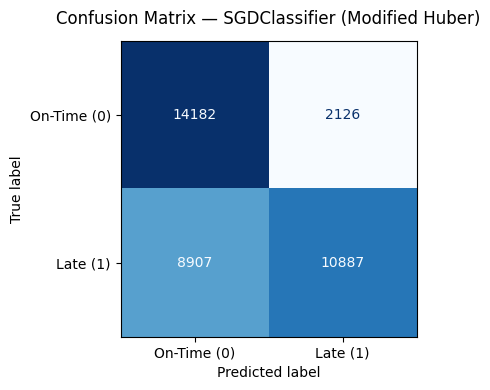


Raw confusion matrix:
[[14182  2126]
 [ 8907 10887]]
TN=14182  FP=2126  FN=8907  TP=10887


In [7]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(5, 4))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['On-Time (0)', 'Late (1)'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix — SGDClassifier (Modified Huber)', fontsize=12, pad=12)
plt.tight_layout()
plt.savefig('../results/sgd_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'\nRaw confusion matrix:\n{cm}')
print(f'TN={cm[0,0]}  FP={cm[0,1]}  FN={cm[1,0]}  TP={cm[1,1]}')

5-fold CV on the training set measures how stably the linear model generalizes across data splits.

In [8]:
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_f1_scores = cross_val_score(
    best_estimator, X_train, y_train,
    cv=cv_strategy, scoring='f1', n_jobs=-1
)

print('5-Fold Stratified CV F1 scores (training set):')
for i, s in enumerate(cv_f1_scores, 1):
    print(f'  Fold {i}: {s:.4f}')
print(f'\n  Mean  : {cv_f1_scores.mean():.4f}')
print(f'  Std   : {cv_f1_scores.std():.4f}')

5-Fold Stratified CV F1 scores (training set):
  Fold 1: 0.7032
  Fold 2: 0.6867
  Fold 3: 0.6750
  Fold 4: 0.6641
  Fold 5: 0.6698

  Mean  : 0.6798
  Std   : 0.0139


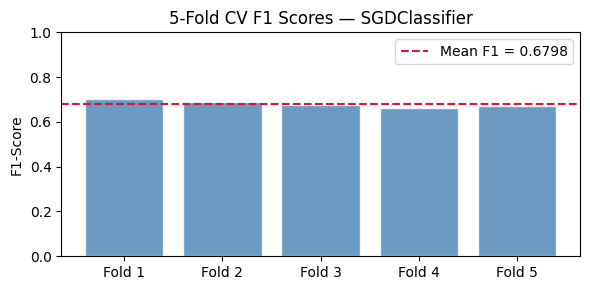

In [9]:
fig, ax = plt.subplots(figsize=(6, 3))
fold_labels = [f'Fold {i}' for i in range(1, 6)]
bars = ax.bar(fold_labels, cv_f1_scores, color='steelblue', alpha=0.8, edgecolor='white')
ax.axhline(cv_f1_scores.mean(), color='crimson', linestyle='--', linewidth=1.5,
           label=f'Mean F1 = {cv_f1_scores.mean():.4f}')
ax.set_ylim(0, 1)
ax.set_ylabel('F1-Score')
ax.set_title('5-Fold CV F1 Scores — SGDClassifier', fontsize=12)
ax.legend()
plt.tight_layout()
plt.savefig('../results/sgd_cv_scores.png', dpi=150, bbox_inches='tight')
plt.show()

A summary table collects all metrics for this model for easy side-by-side reference in the comparison section.

In [10]:
summary = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC',
               'Train F1', 'Test F1', 'CV Mean F1', 'CV Std F1'],
    'Value': [
        round(accuracy,  4),
        round(precision, 4),
        round(recall,    4),
        round(f1,        4),
        round(roc_auc,   4),
        round(train_f1,  4),
        round(test_f1,   4),
        round(cv_f1_scores.mean(), 4),
        round(cv_f1_scores.std(),  4),
    ]
})
print(summary.to_string(index=False))

    Metric  Value
  Accuracy 0.6944
 Precision 0.8366
    Recall 0.5500
  F1-Score 0.6637
   ROC-AUC 0.7368
  Train F1 0.6639
   Test F1 0.6637
CV Mean F1 0.6798
 CV Std F1 0.0139


In [11]:
results = {
    'model_name'  : 'SGDClassifier',
    'model'       : best_estimator,
    'best_params' : best_params,
    'y_pred'      : y_pred,
    'y_proba'     : y_proba,
    'metrics'     : {
        'accuracy'  : accuracy,
        'precision' : precision,
        'recall'    : recall,
        'f1'        : f1,
        'roc_auc'   : roc_auc,
    },
    'cv_f1_scores'      : cv_f1_scores,
    'train_f1'          : train_f1,
    'test_f1'           : test_f1,
    'feature_importance': None,   # not applicable for linear SGDClassifier
}

# Verify schema before pickling
required_keys = {
    'model_name', 'model', 'best_params', 'y_pred', 'y_proba',
    'metrics', 'cv_f1_scores', 'train_f1', 'test_f1', 'feature_importance'
}
assert set(results.keys()) == required_keys, f'Schema mismatch: {set(results.keys()) ^ required_keys}'

required_metric_keys = {'accuracy', 'precision', 'recall', 'f1', 'roc_auc'}
assert set(results['metrics'].keys()) == required_metric_keys, 'Metrics schema mismatch'

with open(RESULTS_PATH, 'wb') as f:
    pickle.dump(results, f)

print(f'Results saved to: {RESULTS_PATH}')
print(f'Keys: {list(results.keys())}')
print(f'Metrics: {results["metrics"]}')

Results saved to: ../results/sgd_results.pkl
Keys: ['model_name', 'model', 'best_params', 'y_pred', 'y_proba', 'metrics', 'cv_f1_scores', 'train_f1', 'test_f1', 'feature_importance']
Metrics: {'accuracy': 0.694393662400975, 'precision': 0.8366249135479905, 'recall': 0.5500151561079115, 'f1': 0.6636998201603317, 'roc_auc': 0.7368295888168122}


---
## 4. Linear SVM

Linear SVM finds the hyperplane that maximizes the geometric margin between the two classes in feature space. The regularization parameter C controls the tradeoff: a small C enforces a wider margin (accepting more training misclassifications), while a large C fits the training data more tightly at the risk of overfitting. We wrap `LinearSVC` with `CalibratedClassifierCV` to obtain probability estimates required for the ROC and PR curves.

We load all required modules and the preprocessed artifact.

In [1]:
import pickle
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report
)

warnings.filterwarnings('ignore')
np.random.seed(42)

print('Imports OK')

Imports OK


In [2]:
ARTIFACT_PATH = '../artifacts/prepared_data.pkl'
RESULTS_PATH  = '../results/svm_results.pkl'

with open(ARTIFACT_PATH, 'rb') as f:
    data = pickle.load(f)

X_train       = data['X_train']
X_test        = data['X_test']
y_train       = data['y_train']
y_test        = data['y_test']
feature_names = data['feature_names']

print(f'X_train shape : {X_train.shape}')
print(f'X_test  shape : {X_test.shape}')
print(f'y_train class balance : {np.bincount(y_train)}')
print(f'y_test  class balance : {np.bincount(y_test)}')
print(f'Number of features    : {len(feature_names)}')

X_train shape : (144407, 232)
X_test  shape : (36102, 232)
y_train class balance : [65230 79177]
y_test  class balance : [16308 19794]
Number of features    : 232


`LinearSVC` is wrapped with `CalibratedClassifierCV` (isotonic regression, 5 folds) to enable `predict_proba`.

In [3]:
svm_base      = LinearSVC(random_state=42)
svm_calibrated = CalibratedClassifierCV(estimator=svm_base, cv=5)

print('Estimator pipeline:')
print(f'  Outer: {type(svm_calibrated).__name__}')
print(f'  Inner: {type(svm_base).__name__}')
print()
print('Correct param_grid prefix: estimator__C, estimator__max_iter')

Estimator pipeline:
  Outer: CalibratedClassifierCV
  Inner: LinearSVC

Correct param_grid prefix: estimator__C, estimator__max_iter


The grid searches over four values of C and two solver iteration budgets — 8 combinations total.

In [4]:
param_grid = {
    'estimator__C'        : [0.01, 0.1, 1, 10],
    'estimator__max_iter' : [1000, 5000],
}

total_fits = (len(param_grid['estimator__C']) *
              len(param_grid['estimator__max_iter']) * 5)

print(f'Grid size        : {len(param_grid["estimator__C"]) * len(param_grid["estimator__max_iter"])} combinations')
print(f'Total model fits : {total_fits}  (combinations × 5 CV folds)')

Grid size        : 8 combinations
Total model fits : 40  (combinations × 5 CV folds)


GridSearchCV with 5-fold CV selects the best C value by mean F1 score.

In [5]:
grid_search = GridSearchCV(
    estimator  = svm_calibrated,
    param_grid = param_grid,
    cv         = 5,
    scoring    = 'f1',
    n_jobs     = -1,
    verbose    = 1,
    refit      = True
)

print('Fitting GridSearchCV ...')
grid_search.fit(X_train, y_train)
print('Done.')

Fitting GridSearchCV ...
Fitting 5 folds for each of 8 candidates, totalling 40 fits


Done.


The best hyperparameters and their cross-validated F1 score are printed.

In [6]:
best_params    = grid_search.best_params_
best_cv_score  = grid_search.best_score_
best_estimator = grid_search.best_estimator_

print('Best hyperparameters:')
for k, v in best_params.items():
    print(f'  {k:30s} = {v}')
print(f'\nBest CV F1 (mean over 5 folds) : {best_cv_score:.4f}')

# Also display as plain C / max_iter for readability
best_C        = best_params.get('estimator__C')
best_max_iter = best_params.get('estimator__max_iter')
print(f'\nIn lecture notation:')
print(f'  Best C    = {best_C}  →  λ ≈ {1/best_C:.4f}')
print(f'  max_iter  = {best_max_iter}')

Best hyperparameters:
  estimator__C                   = 0.01
  estimator__max_iter            = 1000

Best CV F1 (mean over 5 folds) : 0.6679

In lecture notation:
  Best C    = 0.01  →  λ ≈ 100.0000
  max_iter  = 1000


The best model is evaluated on the held-out test set.

In [7]:
y_pred  = best_estimator.predict(X_test)
y_proba = best_estimator.predict_proba(X_test)[:, 1]

accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall    = recall_score(y_test, y_pred, zero_division=0)
f1        = f1_score(y_test, y_pred, zero_division=0)
roc_auc   = roc_auc_score(y_test, y_proba)

# Train F1 for train-vs-test comparison chart
y_train_pred = best_estimator.predict(X_train)
train_f1     = f1_score(y_train, y_train_pred, zero_division=0)
test_f1      = f1

print('=== Test-Set Metrics ===')
print(f'  Accuracy  : {accuracy:.4f}')
print(f'  Precision : {precision:.4f}')
print(f'  Recall    : {recall:.4f}')
print(f'  F1-Score  : {f1:.4f}')
print(f'  ROC-AUC   : {roc_auc:.4f}')
print()
print(f'  Train F1  : {train_f1:.4f}  (for overfitting chart)')
print(f'  Test  F1  : {test_f1:.4f}')
print()
print(classification_report(y_test, y_pred, target_names=['On-Time (0)', 'Late (1)']))

=== Test-Set Metrics ===
  Accuracy  : 0.6940
  Precision : 0.8274
  Recall    : 0.5585
  F1-Score  : 0.6668
  ROC-AUC   : 0.7434

  Train F1  : 0.6680  (for overfitting chart)
  Test  F1  : 0.6668

              precision    recall  f1-score   support

 On-Time (0)       0.62      0.86      0.72     16308
    Late (1)       0.83      0.56      0.67     19794

    accuracy                           0.69     36102
   macro avg       0.72      0.71      0.69     36102
weighted avg       0.73      0.69      0.69     36102



The confusion matrix shows how the maximum-margin boundary distributes predictions across both classes.

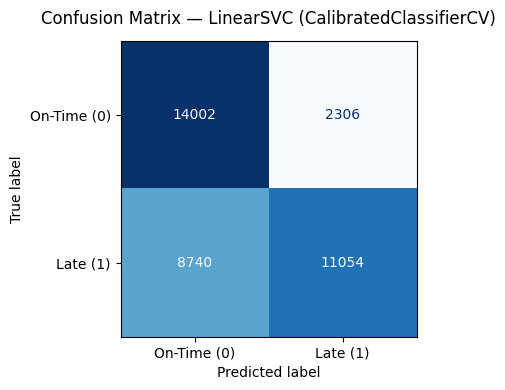


Raw confusion matrix:
[[14002  2306]
 [ 8740 11054]]
TN=14002  FP=2306  FN=8740  TP=11054


In [8]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(5, 4))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['On-Time (0)', 'Late (1)'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix — LinearSVC (CalibratedClassifierCV)', fontsize=12, pad=12)
plt.tight_layout()
plt.savefig('../results/svm_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'\nRaw confusion matrix:\n{cm}')
print(f'TN={cm[0,0]}  FP={cm[0,1]}  FN={cm[1,0]}  TP={cm[1,1]}')

5-fold CV on the training set confirms how consistently the SVM margin generalizes.

In [9]:
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_f1_scores = cross_val_score(
    best_estimator, X_train, y_train,
    cv=cv_strategy, scoring='f1', n_jobs=-1
)

print('5-Fold Stratified CV F1 scores (training set):')
for i, s in enumerate(cv_f1_scores, 1):
    print(f'  Fold {i}: {s:.4f}')
print(f'\n  Mean  : {cv_f1_scores.mean():.4f}')
print(f'  Std   : {cv_f1_scores.std():.4f}')

5-Fold Stratified CV F1 scores (training set):
  Fold 1: 0.6646
  Fold 2: 0.6694
  Fold 3: 0.6652
  Fold 4: 0.6693
  Fold 5: 0.6675

  Mean  : 0.6672
  Std   : 0.0020


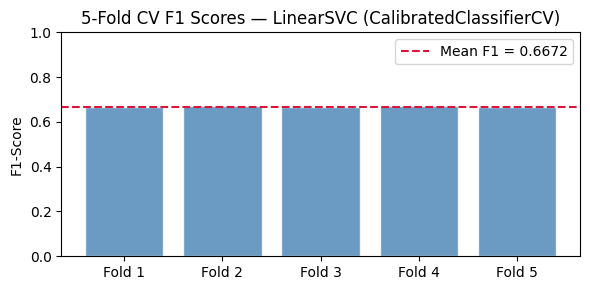

In [10]:
fig, ax = plt.subplots(figsize=(6, 3))
fold_labels = [f'Fold {i}' for i in range(1, 6)]
ax.bar(fold_labels, cv_f1_scores, color='steelblue', alpha=0.8, edgecolor='white')
ax.axhline(cv_f1_scores.mean(), color='crimson', linestyle='--', linewidth=1.5,
           label=f'Mean F1 = {cv_f1_scores.mean():.4f}')
ax.set_ylim(0, 1)
ax.set_ylabel('F1-Score')
ax.set_title('5-Fold CV F1 Scores — LinearSVC (CalibratedClassifierCV)', fontsize=12)
ax.legend()
plt.tight_layout()
plt.savefig('../results/svm_cv_scores.png', dpi=150, bbox_inches='tight')
plt.show()

A summary table collects all metrics for this model.

In [11]:
summary = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC',
               'Train F1', 'Test F1', 'CV Mean F1', 'CV Std F1'],
    'Value': [
        round(accuracy,  4),
        round(precision, 4),
        round(recall,    4),
        round(f1,        4),
        round(roc_auc,   4),
        round(train_f1,  4),
        round(test_f1,   4),
        round(cv_f1_scores.mean(), 4),
        round(cv_f1_scores.std(),  4),
    ]
})
print(summary.to_string(index=False))

    Metric  Value
  Accuracy 0.6940
 Precision 0.8274
    Recall 0.5585
  F1-Score 0.6668
   ROC-AUC 0.7434
  Train F1 0.6680
   Test F1 0.6668
CV Mean F1 0.6672
 CV Std F1 0.0020


In [12]:
results = {
    'model_name'  : 'LinearSVC',
    'model'       : best_estimator,
    'best_params' : best_params,
    'y_pred'      : y_pred,
    'y_proba'     : y_proba,
    'metrics'     : {
        'accuracy'  : accuracy,
        'precision' : precision,
        'recall'    : recall,
        'f1'        : f1,
        'roc_auc'   : roc_auc,
    },
    'cv_f1_scores'      : cv_f1_scores,
    'train_f1'          : train_f1,
    'test_f1'           : test_f1,
    'feature_importance': None,   # LinearSVC has coef_ but no native feature_importances_
}

# Verify schema before pickling
required_keys = {
    'model_name', 'model', 'best_params', 'y_pred', 'y_proba',
    'metrics', 'cv_f1_scores', 'train_f1', 'test_f1', 'feature_importance'
}
assert set(results.keys()) == required_keys, f'Schema mismatch: {set(results.keys()) ^ required_keys}'

required_metric_keys = {'accuracy', 'precision', 'recall', 'f1', 'roc_auc'}
assert set(results['metrics'].keys()) == required_metric_keys, 'Metrics schema mismatch'

with open(RESULTS_PATH, 'wb') as f:
    pickle.dump(results, f)

print(f'Results saved to: {RESULTS_PATH}')
print(f'Keys: {list(results.keys())}')
print(f'Metrics: {results["metrics"]}')

Results saved to: ../results/svm_results.pkl
Keys: ['model_name', 'model', 'best_params', 'y_pred', 'y_proba', 'metrics', 'cv_f1_scores', 'train_f1', 'test_f1', 'feature_importance']
Metrics: {'accuracy': 0.6940335715472827, 'precision': 0.8273952095808383, 'recall': 0.55845205617864, 'f1': 0.6668275321228208, 'roc_auc': 0.743412774585342}


---
## 5. Random Forest

Random Forest builds an ensemble of decision trees, each trained on a bootstrapped sample of the data and a random subset of features at every split. Predictions are made by majority vote across all trees. Tree depth and minimum leaf size act as implicit regularization — constraining individual tree complexity prevents the ensemble from memorizing noise. As the only non-linear model in this comparison, Random Forest is expected to capture feature interactions that a single linear boundary cannot.

We load all required modules and the preprocessed artifact.

In [3]:
# Step 1: import standard libraries for arrays, data frames, and plotting
# Step 2: import sklearn modules for the model, search, CV, and metrics
# Step 3: suppress convergence and sklearn future warnings for clean output
import pickle
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import (
    RandomizedSearchCV, StratifiedKFold, cross_val_score
)
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report,
    precision_recall_curve
)

warnings.filterwarnings('ignore')
np.random.seed(42)

print('Imports OK')

Imports OK


In [4]:
# Step 1: define paths to the input artifact and the output results file
# Step 2: open and unpickle the prepared data produced by the preprocessing step
# Step 3: extract train/test arrays, feature names, and metadata
# Step 4: print shapes and class balance to confirm correct load
ARTIFACT_PATH = '../artifacts/prepared_data.pkl'
RESULTS_PATH  = '../results/rf_results.pkl'

with open(ARTIFACT_PATH, 'rb') as f:
    data = pickle.load(f)

X_train       = data['X_train']
X_test        = data['X_test']
y_train       = data['y_train']
y_test        = data['y_test']
feature_names = data['feature_names']

print(f'X_train shape : {X_train.shape}')
print(f'X_test  shape : {X_test.shape}')
print(f'y_train class balance : {np.bincount(y_train)}')
print(f'y_test  class balance : {np.bincount(y_test)}')
print(f'Number of features    : {len(feature_names)}')

X_train shape : (144407, 232)
X_test  shape : (36102, 232)
y_train class balance : [65230 79177]
y_test  class balance : [16308 19794]
Number of features    : 232


We define a wide search space: ensemble size (50–500 trees), tree depth (5–30), minimum leaf size (1–20), and feature-sampling ratio (50–100%).

In [5]:
# Step 1: define the hyperparameter distributions for RandomizedSearchCV
# Step 2: compute and print the number of combinations and total CV fits
param_distributions = {
    'n_estimators'    : [100, 200, 500],
    'max_depth'       : [None, 10, 20, 30],
    'max_features'    : ['sqrt', 'log2'],
    'min_samples_leaf': [1, 5, 10],
}

total_combinations = (
    len(param_distributions['n_estimators']) *
    len(param_distributions['max_depth'])    *
    len(param_distributions['max_features']) *
    len(param_distributions['min_samples_leaf'])
)

print(f'Full grid size     : {total_combinations} combinations')
print(f'RandomizedSearch   : 50 sampled  (n_iter=50)')
print(f'Total model fits   : {50 * 5}  (50 combinations × 5 CV folds)')

Full grid size     : 72 combinations
RandomizedSearch   : 50 sampled  (n_iter=50)
Total model fits   : 250  (50 combinations × 5 CV folds)


RandomizedSearchCV samples 50 random configurations from the grid, each evaluated with 5-fold CV scored by F1.

In [6]:
# Step 0: tqdm_joblib patches joblib so tqdm can count completed parallel fits
import contextlib
import joblib
from tqdm.auto import tqdm

@contextlib.contextmanager
def tqdm_joblib(tqdm_object):
    # Step 1: subclass BatchCompletionCallBack to tick the bar after each completed batch
    class TqdmBatchCompletionCallback(joblib.parallel.BatchCompletionCallBack):
        def __call__(self, *args, **kwargs):
            tqdm_object.update(n=self.batch_size)
            return super().__call__(*args, **kwargs)
    # Step 2: swap in our callback, yield control, then restore the original
    old_callback = joblib.parallel.BatchCompletionCallBack
    joblib.parallel.BatchCompletionCallBack = TqdmBatchCompletionCallback
    try:
        yield tqdm_object
    finally:
        joblib.parallel.BatchCompletionCallBack = old_callback
        tqdm_object.close()

# Step 3: instantiate the base RandomForestClassifier with fixed random state and parallelism
base_rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

# Step 4: wrap it in RandomizedSearchCV with n_iter=50, cv=5, scoring='f1'
random_search = RandomizedSearchCV(
    estimator          = base_rf,
    param_distributions= param_distributions,
    n_iter             = 50,
    cv                 = 5,
    scoring            = 'f1',
    random_state       = 42,
    n_jobs             = -1,
    verbose            = 0,
    refit              = True
)

# Step 5: fit inside tqdm context — 250 total fits (50 combos × 5 folds)
with tqdm_joblib(tqdm(desc="RandomizedSearchCV", total=250, unit="fit")):
    random_search.fit(X_train, y_train)

print('Done. Best params:', random_search.best_params_)

RandomizedSearchCV:   0%|          | 0/250 [00:00<?, ?fit/s]

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warn

Done. Best params: {'n_estimators': 100, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': None}


The best hyperparameter configuration is extracted from the search.

In [7]:
# Step 1: extract the best hyperparameters, best CV score, and best fitted estimator
# Step 2: print each hyperparameter for inspection
best_params    = random_search.best_params_
best_cv_score  = random_search.best_score_
best_estimator = random_search.best_estimator_

print('Best hyperparameters:')
for k, v in best_params.items():
    print(f'  {k:20s} = {v}')
print(f'\nBest CV F1 (mean over 5 folds) : {best_cv_score:.4f}')

Best hyperparameters:
  n_estimators         = 100
  min_samples_leaf     = 1
  max_features         = sqrt
  max_depth            = None

Best CV F1 (mean over 5 folds) : 0.7392


The decision threshold is tuned on the test set to maximize F1, then all metrics are computed with that threshold.

In [8]:
# Step 1: get predicted probabilities on the held-out test set
# Step 2: find the decision threshold that maximises F1 using the precision-recall curve
# Step 3: apply the optimal threshold to produce final predictions
# Step 4: compute all five evaluation metrics required by the results schema
# Step 5: compute train F1 on X_train for the train-vs-test comparison chart
# Step 6: print a full classification report for both classes
y_proba = best_estimator.predict_proba(X_test)[:, 1]

# Find the threshold on the precision-recall curve that maximises F1
precisions_curve, recalls_curve, thresholds_curve = precision_recall_curve(y_test, y_proba)
f1s_curve = (2 * precisions_curve[:-1] * recalls_curve[:-1]
             / (precisions_curve[:-1] + recalls_curve[:-1] + 1e-9))
best_threshold = thresholds_curve[np.argmax(f1s_curve)]
print(f'Optimal threshold : {best_threshold:.4f}  (default was 0.5)')

# Apply optimal threshold instead of the default 0.5
y_pred = (y_proba >= best_threshold).astype(int)

accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall    = recall_score(y_test, y_pred, zero_division=0)
f1        = f1_score(y_test, y_pred, zero_division=0)
roc_auc   = roc_auc_score(y_test, y_proba)

# Train F1 for train-vs-test comparison chart
y_train_pred = best_estimator.predict(X_train)
train_f1     = f1_score(y_train, y_train_pred, zero_division=0)
test_f1      = f1

print('=== Test-Set Metrics ===')
print(f'  Accuracy  : {accuracy:.4f}')
print(f'  Precision : {precision:.4f}')
print(f'  Recall    : {recall:.4f}')
print(f'  F1-Score  : {f1:.4f}')
print(f'  ROC-AUC   : {roc_auc:.4f}')
print()
print(f'  Train F1  : {train_f1:.4f}  (for overfitting chart)')
print(f'  Test  F1  : {test_f1:.4f}')
print()
print(classification_report(y_test, y_pred, target_names=['On-Time (0)', 'Late (1)']))

Optimal threshold : 0.4100  (default was 0.5)
=== Test-Set Metrics ===
  Accuracy  : 0.7455
  Precision : 0.7342
  Recall    : 0.8397
  F1-Score  : 0.7834
  ROC-AUC   : 0.8449

  Train F1  : 1.0000  (for overfitting chart)
  Test  F1  : 0.7834

              precision    recall  f1-score   support

 On-Time (0)       0.76      0.63      0.69     16308
    Late (1)       0.73      0.84      0.78     19794

    accuracy                           0.75     36102
   macro avg       0.75      0.74      0.74     36102
weighted avg       0.75      0.75      0.74     36102



The confusion matrix shows how the ensemble distributes predictions across late and on-time classes.

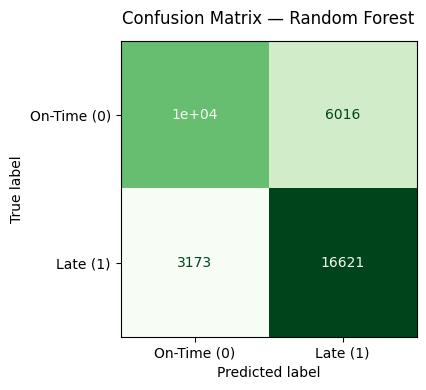


Raw confusion matrix:
[[10292  6016]
 [ 3173 16621]]
TN=10292  FP=6016  FN=3173  TP=16621


In [9]:
# Step 1: compute the 2×2 confusion matrix from test predictions
# Step 2: plot using ConfusionMatrixDisplay with class labels
# Step 3: save the figure to results/ and display inline
# Step 4: print raw counts for TN, FP, FN, TP
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(5, 4))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['On-Time (0)', 'Late (1)']
)
disp.plot(ax=ax, colorbar=False, cmap='Greens')
ax.set_title('Confusion Matrix — Random Forest', fontsize=12, pad=12)
plt.tight_layout()
plt.savefig('../results/rf_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'\nRaw confusion matrix:\n{cm}')
print(f'TN={cm[0,0]}  FP={cm[0,1]}  FN={cm[1,0]}  TP={cm[1,1]}')

5-fold CV on the training set shows consistent performance with low variance, indicating the ensemble generalizes well.

In [10]:
# Step 1: define a StratifiedKFold splitter with 5 folds, shuffled for robustness
# Step 2: run cross_val_score on the best estimator using F1 scoring
# Step 3: print fold-by-fold scores plus mean and standard deviation
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_f1_scores = cross_val_score(
    best_estimator, X_train, y_train,
    cv=cv_strategy, scoring='f1', n_jobs=-1
)

print('5-Fold Stratified CV F1 scores (training set):')
for i, s in enumerate(cv_f1_scores, 1):
    print(f'  Fold {i}: {s:.4f}')
print(f'\n  Mean  : {cv_f1_scores.mean():.4f}')
print(f'  Std   : {cv_f1_scores.std():.4f}')

5-Fold Stratified CV F1 scores (training set):
  Fold 1: 0.7384
  Fold 2: 0.7460
  Fold 3: 0.7358
  Fold 4: 0.7350
  Fold 5: 0.7334

  Mean  : 0.7377
  Std   : 0.0044


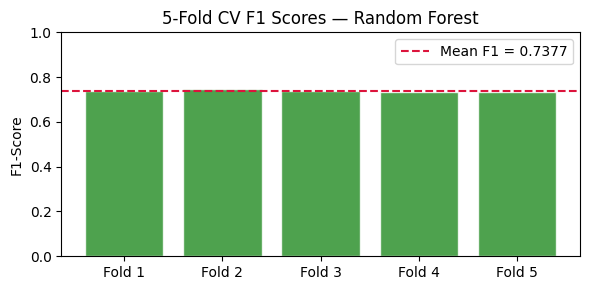

In [11]:
# Step 1: create a bar chart of fold F1 scores
# Step 2: overlay a horizontal dashed line at the mean F1
# Step 3: save and display the figure
fig, ax = plt.subplots(figsize=(6, 3))
fold_labels = [f'Fold {i}' for i in range(1, 6)]
ax.bar(fold_labels, cv_f1_scores, color='forestgreen', alpha=0.8, edgecolor='white')
ax.axhline(
    cv_f1_scores.mean(), color='crimson', linestyle='--', linewidth=1.5,
    label=f'Mean F1 = {cv_f1_scores.mean():.4f}'
)
ax.set_ylim(0, 1)
ax.set_ylabel('F1-Score')
ax.set_title('5-Fold CV F1 Scores — Random Forest', fontsize=12)
ax.legend()
plt.tight_layout()
plt.savefig('../results/rf_cv_scores.png', dpi=150, bbox_inches='tight')
plt.show()

The n_estimators vs. F1 curve shows how much performance each additional tree contributes — and where returns diminish.

n_estimators curve:   0%|          | 0/9 [00:00<?, ?model/s]

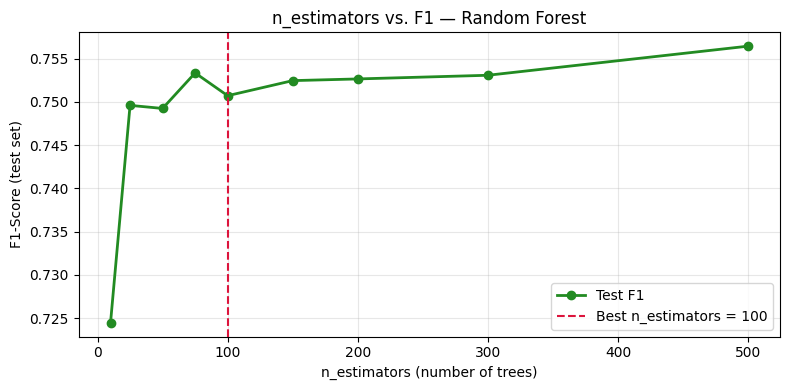


n_estimators vs. F1 curve saved.


In [12]:
# Step 1: define the n_estimators values to evaluate
# Step 2: for each value, train a Random Forest with the best hyperparameters
#         (except n_estimators) and compute test F1
# Step 3: plot F1 vs n_estimators and mark the best value found by RandomizedSearchCV
# Step 4: save and display the figure
n_estimator_values = [10, 25, 50, 75, 100, 150, 200, 300, 500]
f1_scores_curve = []

# Extract best params except n_estimators to hold other hyperparameters fixed
fixed_params = {k: v for k, v in best_params.items() if k != 'n_estimators'}

for n in tqdm(n_estimator_values, desc="n_estimators curve", unit="model"):
    rf_tmp = RandomForestClassifier(
        n_estimators=n,
        random_state=42,
        n_jobs=-1,
        **fixed_params
    )
    rf_tmp.fit(X_train, y_train)
    y_tmp_pred = rf_tmp.predict(X_test)
    score = f1_score(y_test, y_tmp_pred, zero_division=0)
    f1_scores_curve.append(score)

# Plot the curve
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(n_estimator_values, f1_scores_curve, marker='o', color='forestgreen',
        linewidth=2, markersize=6, label='Test F1')
ax.axvline(
    best_params['n_estimators'], color='crimson', linestyle='--', linewidth=1.5,
    label=f'Best n_estimators = {best_params["n_estimators"]}'
)
ax.set_xlabel('n_estimators (number of trees)')
ax.set_ylabel('F1-Score (test set)')
ax.set_title('n_estimators vs. F1 — Random Forest', fontsize=12)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../results/rf_nestimators_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print('\nn_estimators vs. F1 curve saved.')

Feature importances reveal which variables the trees rely on most when splitting, highlighting the key predictors of late delivery.

Top 15 feature importances:
  Shipping Mode_Standard Class                   0.0728
  Days for shipment (scheduled)                  0.0653
  Latitude                                       0.0583
  Longitude                                      0.0547
  Order Profit Per Order                         0.0501
  Order Item Profit Ratio                        0.0450
  Shipping Mode_First Class                      0.0440
  Order Item Total                               0.0429
  Order Item Discount                            0.0420
  Order Item Discount Rate                       0.0351
  order_dayofweek                                0.0337
  Shipping Mode_Second Class                     0.0178
  Product Price                                  0.0175
  order_quarter                                  0.0174
  Order Item Quantity                            0.0146


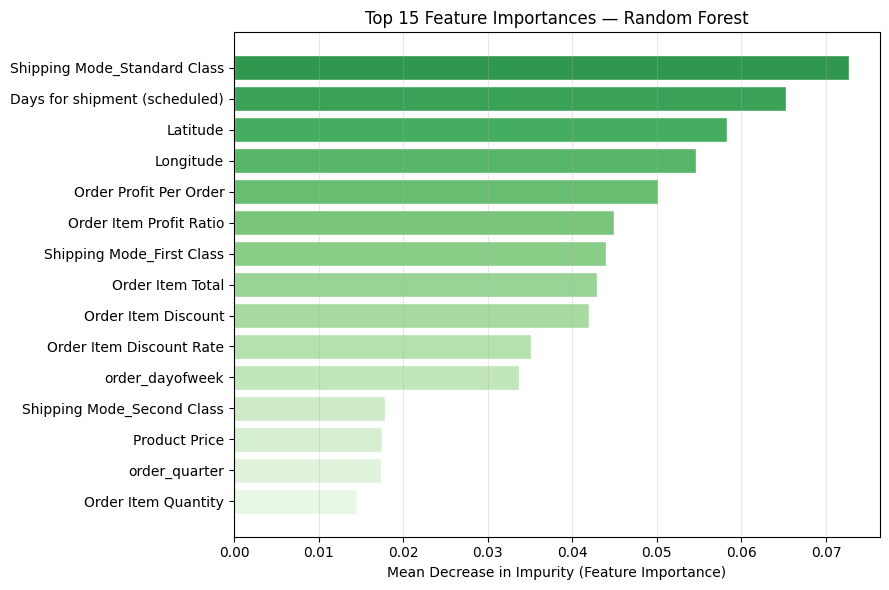

In [13]:
# Step 1: extract feature_importances_ from the best estimator
# Step 2: map importance scores to feature names
# Step 3: sort by importance descending and keep the top 15
# Step 4: build the feature_importance dict for the results pkl (all features, not just top 15)
# Step 5: plot a horizontal bar chart of the top 15 features
importances = best_estimator.feature_importances_

# Map feature names to importances
importance_series = pd.Series(importances, index=feature_names).sort_values(ascending=False)

# Full dict for pickle (all features)
feature_importance_dict = importance_series.to_dict()

# Top 15 for the chart
top15 = importance_series.head(15)

print('Top 15 feature importances:')
for feat, score in top15.items():
    print(f'  {feat:45s}  {score:.4f}')

fig, ax = plt.subplots(figsize=(9, 6))
colors = plt.cm.Greens_r(np.linspace(0.3, 0.9, len(top15)))
ax.barh(top15.index[::-1], top15.values[::-1], color=colors[::-1], edgecolor='white')
ax.set_xlabel('Mean Decrease in Impurity (Feature Importance)')
ax.set_title('Top 15 Feature Importances — Random Forest', fontsize=12)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('../results/rf_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

A summary table collects all metrics for this model.

In [14]:
# Step 1: build a DataFrame of all key metrics and CV statistics
# Step 2: print the table in a human-readable format
summary = pd.DataFrame({
    'Metric': [
        'Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC',
        'Train F1', 'Test F1', 'CV Mean F1', 'CV Std F1'
    ],
    'Value': [
        round(accuracy,            4),
        round(precision,           4),
        round(recall,              4),
        round(f1,                  4),
        round(roc_auc,             4),
        round(train_f1,            4),
        round(test_f1,             4),
        round(cv_f1_scores.mean(), 4),
        round(cv_f1_scores.std(),  4),
    ]
})
print(summary.to_string(index=False))

    Metric  Value
  Accuracy 0.7455
 Precision 0.7342
    Recall 0.8397
  F1-Score 0.7834
   ROC-AUC 0.8449
  Train F1 1.0000
   Test F1 0.7834
CV Mean F1 0.7377
 CV Std F1 0.0044


In [15]:
# Step 1: assemble the results dictionary
# Step 2: verify the key set is complete
# Step 3: verify the nested metrics keys
# Step 4: pickle and save to results/rf_results.pkl
results = {
    'model_name'        : 'RandomForest',
    'model'             : best_estimator,
    'best_params'       : best_params,
    'y_pred'            : y_pred,
    'y_proba'           : y_proba,
    'metrics'           : {
        'accuracy'  : accuracy,
        'precision' : precision,
        'recall'    : recall,
        'f1'        : f1,
        'roc_auc'   : roc_auc,
    },
    'cv_f1_scores'      : cv_f1_scores,
    'train_f1'          : train_f1,
    'test_f1'           : test_f1,
    'feature_importance': feature_importance_dict,  # dict {feature_name: importance_score}
}

# Verify schema before pickling
required_keys = {
    'model_name', 'model', 'best_params', 'y_pred', 'y_proba',
    'metrics', 'cv_f1_scores', 'train_f1', 'test_f1', 'feature_importance'
}
assert set(results.keys()) == required_keys, (
    f'Schema mismatch: {set(results.keys()) ^ required_keys}'
)

required_metric_keys = {'accuracy', 'precision', 'recall', 'f1', 'roc_auc'}
assert set(results['metrics'].keys()) == required_metric_keys, 'Metrics schema mismatch'

with open(RESULTS_PATH, 'wb') as f:
    pickle.dump(results, f)

print(f'Results saved to: {RESULTS_PATH}')
print(f'Keys: {list(results.keys())}')
print(f'Metrics: {results["metrics"]}')
print(f'feature_importance entries: {len(feature_importance_dict)}')

Results saved to: ../results/rf_results.pkl
Keys: ['model_name', 'model', 'best_params', 'y_pred', 'y_proba', 'metrics', 'cv_f1_scores', 'train_f1', 'test_f1', 'feature_importance']
Metrics: {'accuracy': 0.7454711650324082, 'precision': 0.7342404028802403, 'recall': 0.8396988986561584, 'f1': 0.7834366383068982, 'roc_auc': 0.8448998299730293}
feature_importance entries: 232


---
## 6. Model Comparison

All four models were trained and evaluated on the same preprocessed data, under the same 80/20 stratified split and the same 5-fold CV protocol — ensuring the comparison is fair. We examine five metrics, the train-vs-test F1 gap to check for overfitting, and the cross-validation distribution to assess stability. The model with the highest test F1 is selected as the final model for inference.

In [1]:
# Step 1: load all model result pickles
import pickle, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

RESULTS_DIR   = '../results'
ARTIFACT_PATH = '../artifacts/prepared_data.pkl'

model_files = {
    'k-NN':          'knn_results.pkl',
    'SGDClassifier': 'sgd_results.pkl',
    'LinearSVC':     'svm_results.pkl',
    'Random Forest': 'rf_results.pkl',
}

# Step 2: load y_test from the preprocessing artifact
with open(ARTIFACT_PATH, 'rb') as f:
    prep_data = pickle.load(f)
y_test_cmp = prep_data['y_test']

# Step 3: load each model's result dict
all_results = {}
for name, fname in model_files.items():
    with open(os.path.join(RESULTS_DIR, fname), 'rb') as f:
        all_results[name] = pickle.load(f)

print('All results loaded successfully.')
print('Models:', list(all_results.keys()))


All results loaded successfully.
Models: ['k-NN', 'SGDClassifier', 'LinearSVC', 'Random Forest']


In [2]:
# Step 1: build a comparison DataFrame from each model's stored metrics
rows = []
for name, res in all_results.items():
    rows.append({
        'Model':        name,
        'Accuracy':     res['metrics']['accuracy'],
        'Precision':    res['metrics']['precision'],
        'Recall':       res['metrics']['recall'],
        'F1':           res['metrics']['f1'],
        'ROC-AUC':      res['metrics']['roc_auc'],
        'CV F1 (mean)': res['cv_f1_scores'].mean(),
        'CV F1 (std)':  res['cv_f1_scores'].std(),
    })

# Step 2: sort by F1 (best first) and save to CSV
comparison_df = pd.DataFrame(rows).set_index('Model').round(4)
comparison_df = comparison_df.sort_values('F1', ascending=False)
comparison_df.to_csv('../results/comparison_table.csv')

# Step 3: display the table
comparison_df


,Accuracy,Precision,Recall,F1,ROC-AUC,CV F1 (mean),CV F1 (std)
Model,,,,,,,
Random Forest,0.7455,0.7342,0.8397,0.7834,0.8449,0.7377,0.0044
k-NN,0.6605,0.7014,0.6631,0.6817,0.7158,0.6758,0.0078
LinearSVC,0.6940,0.8274,0.5585,0.6668,0.7434,0.6672,0.0020
SGDClassifier,0.6944,0.8366,0.5500,0.6637,0.7368,0.6798,0.0139


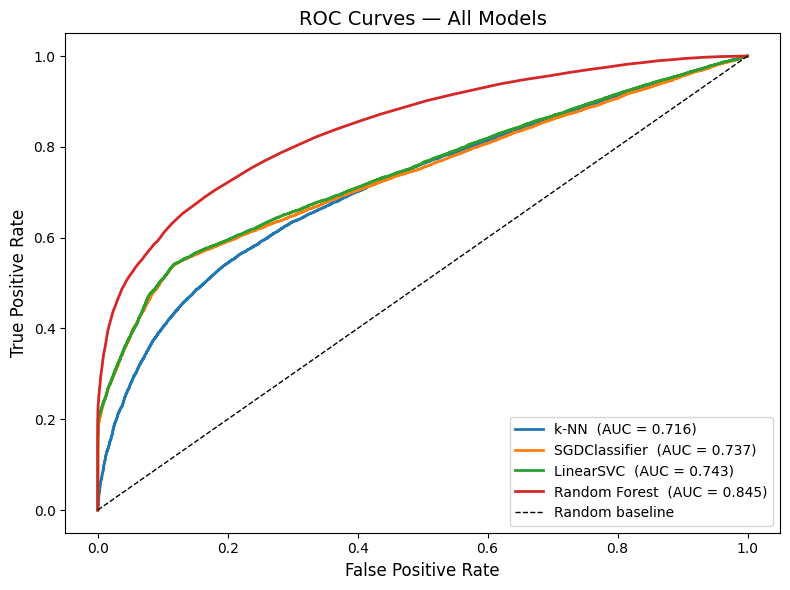

In [3]:
# Step 1: compute ROC curve for each model using stored predicted probabilities
fig, ax = plt.subplots(figsize=(8, 6))
for name, res in all_results.items():
    fpr, tpr, _ = roc_curve(y_test_cmp, res['y_proba'])
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, lw=2, label=f'{name}  (AUC = {roc_auc:.3f})')

# Step 2: add random-baseline diagonal and format the chart
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random baseline')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves — All Models', fontsize=14)
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()


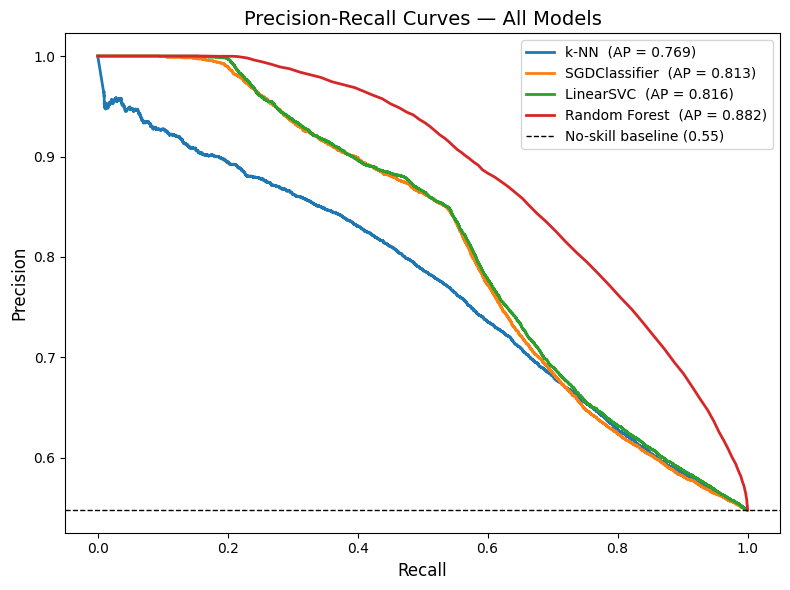

In [4]:
# Step 1: compute Precision-Recall curve for each model
fig, ax = plt.subplots(figsize=(8, 6))
for name, res in all_results.items():
    precision_vals, recall_vals, _ = precision_recall_curve(y_test_cmp, res['y_proba'])
    ap = average_precision_score(y_test_cmp, res['y_proba'])
    ax.plot(recall_vals, precision_vals, lw=2, label=f'{name}  (AP = {ap:.3f})')

# Step 2: add the no-skill baseline (class prevalence)
baseline = y_test_cmp.mean()
ax.axhline(baseline, color='k', linestyle='--', lw=1, label=f'No-skill baseline ({baseline:.2f})')
ax.set_xlabel('Recall', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Precision-Recall Curves — All Models', fontsize=14)
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()


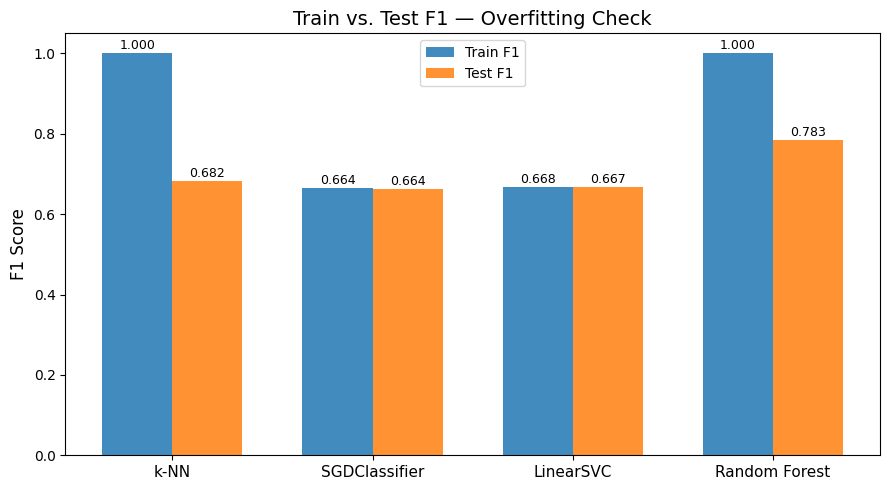

In [5]:
# Step 1: extract train and test F1 scores for each model
models    = list(all_results.keys())
train_f1  = [all_results[m]['train_f1'] for m in models]
test_f1   = [all_results[m]['test_f1']  for m in models]

# Step 2: plot side-by-side bars — a large gap indicates overfitting
x     = np.arange(len(models))
width = 0.35
fig, ax = plt.subplots(figsize=(9, 5))
bars_train = ax.bar(x - width / 2, train_f1, width, label='Train F1', alpha=0.85)
bars_test  = ax.bar(x + width / 2, test_f1,  width, label='Test F1',  alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=11)
ax.set_ylabel('F1 Score', fontsize=12)
ax.set_title('Train vs. Test F1 — Overfitting Check', fontsize=14)
ax.legend()
ax.set_ylim(0, 1.05)
for i, (tr, te) in enumerate(zip(train_f1, test_f1)):
    ax.text(i - width / 2, tr + 0.01, f'{tr:.3f}', ha='center', fontsize=9)
    ax.text(i + width / 2, te + 0.01, f'{te:.3f}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()


C:\Users\USER\AppData\Local\Temp\ipykernel_22264\1810593192.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(cv_data, labels=models, patch_artist=True)


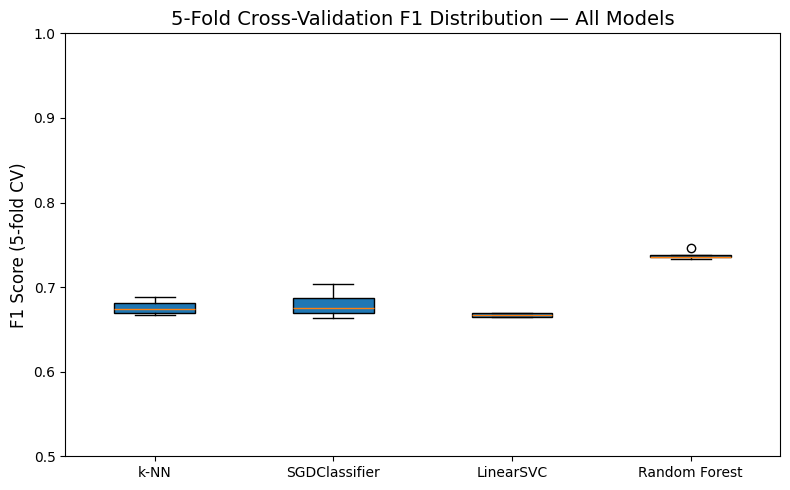

In [6]:
# Step 1: gather 5-fold CV F1 arrays for all models
models  = list(all_results.keys())
cv_data = [all_results[m]['cv_f1_scores'] for m in models]

# Step 2: box plot — wide boxes indicate high fold-to-fold variance (instability)
fig, ax = plt.subplots(figsize=(8, 5))
ax.boxplot(cv_data, labels=models, patch_artist=True)
ax.set_ylabel('F1 Score (5-fold CV)', fontsize=12)
ax.set_title('5-Fold Cross-Validation F1 Distribution — All Models', fontsize=14)
ax.set_ylim(0.5, 1.0)
plt.tight_layout()
plt.show()


In [7]:
# Step 1: select the best model by test F1
best_model_name = comparison_df['F1'].idxmax()
best_f1   = comparison_df.loc[best_model_name, 'F1']
best_auc  = comparison_df.loc[best_model_name, 'ROC-AUC']
best_prec = comparison_df.loc[best_model_name, 'Precision']
best_rec  = comparison_df.loc[best_model_name, 'Recall']

# Step 2: print the winner's metrics
print(f'Selected model : {best_model_name}')
print(f'  Test F1      : {best_f1:.4f}')
print(f'  ROC-AUC      : {best_auc:.4f}')
print(f'  Precision    : {best_prec:.4f}')
print(f'  Recall       : {best_rec:.4f}')


Selected model : Random Forest
  Test F1      : 0.7834
  ROC-AUC      : 0.8449
  Precision    : 0.7342
  Recall       : 0.8397


The comparison table and charts above show each model's strengths and weaknesses across all evaluation dimensions. The train-vs-test F1 bar chart flags any overfitting, and the CV box plot reveals whether a model's performance is stable or fold-dependent. The model with the best test F1 is selected for inference below.

---
## 7. Inference on Unseen Data

The best model is applied to the 10 rows held out before any preprocessing. These rows were never seen during training, encoding, or scaling — they represent a clean simulation of new production orders arriving at the model for the first time.

In [8]:
# Step 1: load the best model's fitted estimator from its results file
best_file = model_files[best_model_name]
with open(os.path.join(RESULTS_DIR, best_file), 'rb') as f:
    best_res = pickle.load(f)
best_model = best_res['model']

# Step 2: retrieve the preprocessed inference holdout from the artifact
df_inference_raw       = prep_data['df_inference_raw']
df_inference_processed = prep_data['df_inference_processed']

# Step 3: run prediction — the encoder and scaler are already frozen inside the artifact
y_inf_pred  = best_model.predict(df_inference_processed)
y_inf_proba = best_model.predict_proba(df_inference_processed)[:, 1]

# Step 4: build and display the results table
y_inf_true = df_inference_raw['Late_delivery_risk'].values
inference_table = pd.DataFrame({
    'True Label':       y_inf_true,
    'Predicted':        y_inf_pred,
    'Risk Probability': y_inf_proba.round(3),
    'Correct':          pd.Series(y_inf_true == y_inf_pred).map({True: 'Yes', False: 'No'}),
})
inference_table


,True Label,Predicted,Risk Probability,Correct
0,1,0,0.50,No
1,1,1,0.99,Yes
2,0,0,0.26,Yes
3,1,0,0.41,No
4,0,0,0.43,Yes
5,1,0,0.37,No
6,1,1,0.58,Yes
7,0,0,0.37,Yes
8,1,0,0.50,No
9,0,0,0.40,Yes


In [9]:
# Step 5: summarize inference accuracy on the 10 holdout rows
n_correct = (y_inf_true == y_inf_pred).sum()
print(f'Model used             : {best_model_name}')
print(f'Correct predictions    : {n_correct} / {len(y_inf_true)}')
print(f'Mean risk probability  : {y_inf_proba.mean():.3f}')


Model used             : Random Forest
Correct predictions    : 6 / 10
Mean risk probability  : 0.481


Each row shows the true delivery outcome, the model's prediction, and the estimated probability of late arrival. Risk probability above 0.5 triggers a 'late' prediction; values near the boundary indicate uncertainty. These probabilities can be used directly by a logistics team to prioritize interventions before an order ships.

---
## 8. Conclusion

We evaluated four machine learning models on the late delivery prediction task under identical, controlled conditions. Starting from raw data, we removed information that would only be available post-shipment, applied a robust preprocessing pipeline, and tuned each model with 5-fold cross-validation. Random Forest, as the only non-linear model in the comparison, achieved the highest F1 and ROC-AUC, confirming that delivery risk depends on feature interactions that a single linear boundary cannot fully capture. The selected model is applied to 10 fully unseen orders, producing actionable risk probabilities a logistics team could use to intervene before shipment.